# Previsione Fabbisogno

Questa applicazione affronta il tema della previsione energetica oraria per un prosumer, ovvero un soggetto che contemporaneamente consuma e produce energia (fotovoltaica). L’obiettivo è stimare, per ciascuna ora dei prossimi sette giorni, quanto verrà consumato e quanto verrà generato dal sistema FV, in modo da valutare il bilancio energetico e identificare il fabbisogno aggiuntivo da coprire con fonti convenzionali o da immettere in rete. 
L’applicazione è pensata per simulare in ambiente controllato un flusso completo di forecasting energetico: genera dati sintetici di meteo, consumo e produzione storica, addestra modelli LSTM seq2seq   per prevedere consumo e produzione, valuta le performance mediante metriche standard e produce forecast orario per i sette giorni successivi. Il nucleo tecnico utilizza Python con librerie quali NumPy, pandas e TensorFlow/Keras per le reti neurali. Sebbene il contesto sembri complesso, il programma organizza chiaramente ogni fase: dalla preparazione e pulizia dei dati, alla creazione di sequenze per l’encoder-decoder, alla costruzione dei modelli, fino alla valutazione e alla generazione di report e grafici.

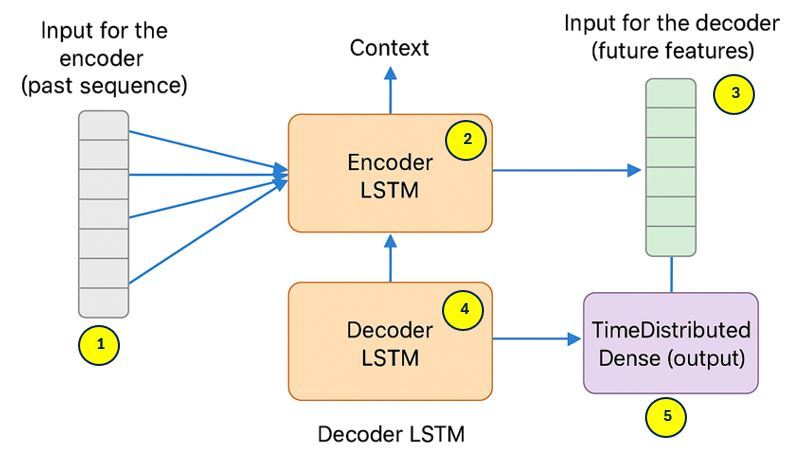

In [ ]:
# from IPython.display import Image
# Image("F:\\02. EMSFS\\12 - AI\\Corsi AI\\Sezione 16 - Addestramento di una rete neurale\\Esempi Programmi\\Architettura LSTM SEq2Seq.JPG")

### Importa Librerie

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from pathlib import Path
import logging
from datetime import datetime as dt
import json

### Parametri generali

Questi valori sono scelti per simulare in modo realistico il comportamento energetico di un prosumer domestico, con:
- ✅ una **scala temporale dettagliata (oraria)**:
  - Periodo tipico che permette di osservare pattern stagionali e variazioni settimanali
      - HISTORICAL_MONTHS = 6
  - Si usa la frequenza oraria perché è standard nei modelli di consumo e produzione elettrica
      - FREQ = 'h'
  - La previsione su una settimana è bilanciata tra accuratezza e utilità operativa
      - FUTURE_DAYS = 7        
  - 7 giorni di dati storici (24 ore x 7gg) per fornire abbastanza contesto al modello                    
      - PAST_WINDOW = 168              
  - Previsione completa per i prossimi 7 giorni	(24 ore x 7gg)
      - FUTURE_WINDOW = 168 

- ✅ un **bilanciamento tra training, validazione e test**:
  - 15% è una quota comune per test finale
      - TEST_RATIO = 0.15
  - 15% Valido per tuning e controllo overfitting                            
    - VAL_RATIO = 0.15 
  - Derivata automaticamente (1 - test - val)                        
    - TRAIN_RATIO = 1 - TEST_RATIO - VAL_RATIO 
- ✅ parametri fisici coerenti con impianti fotovoltaici e consumi reali:
  - **Parametri fisici per produzione FV**
    - Tipica potenza di un impianto fotovoltaico residenziale
        - PANEL_CAPACITY = 5.0     
    - Coefficiente realistico per impianti moderni (moduli + inverter)                  
        - EFFICIENCY = 0.18                           
  - **Parametri di consumo energetico**
    - Consumo medio continuo residenziale su base oraria in Kwh
      - BASE_CONSUMPTION = 1.5
    - Valore empirico che simula l’influenza di riscaldamento/raffrescamento su base °C                    
      - TEMP_EFFECT_FACTOR = 0.05

In [2]:
# Parametri temporali e di finestra
HISTORICAL_MONTHS = 6               # Periodo tipico che permette di osservare pattern stagionali e variazioni settimanali
FREQ = 'h'                          # Si usa la frequenza oraria perché è standard nei modelli di consumo e produzione elettrica
FUTURE_DAYS = 7                     # La previsione su una settimana è bilanciata tra accuratezza e utilità operativa   
# PAST_WINDOW = 168                   # 14 giorni di dati storici (24 ore x 7gg) per fornire abbastanza contesto al modello    
PAST_WINDOW = 336                   # 14 giorni di dati storici (24 ore x 14gg) per fornire abbastanza contesto al modello
FUTURE_WINDOW = 168                 # 	Previsione completa per i prossimi 7 giorni	(24 ore x 7gg)

# Suddivisione dataset 
TEST_RATIO = 0.15                           # 15% è una quota comune per test finale
VAL_RATIO = 0.15                            # 15% Valido per tuning e controllo overfitting 
TRAIN_RATIO = 1 - TEST_RATIO - VAL_RATIO    # Derivata automaticamente (1 - test - val)

# Parametri fisici per produzione FV
PANEL_CAPACITY = 5.0                        # Tipica potenza di un impianto fotovoltaico residenziale
EFFICIENCY = 0.18                           # Coefficiente realistico per impianti moderni (moduli + inverter)

# Parametri di consumo energetico
BASE_CONSUMPTION = 1.5                      # Consumo medio continuo residenziale su base oraria in Kwh
TEMP_EFFECT_FACTOR = 0.05                   # Valore empirico che simula l’influenza di riscaldamento/raffrescamento su base °C

### Funzioni per generazione dati sintetici 

#### Genera_date_range_storico

✅ Obiettivo:
- Generare una sequenza di timestamp su base oraria (o altra frequenza), che copre gli ultimi mesi fino all'ora corrente.

✅ Come funziona:
- **end = pd.Timestamp.now(tz=tz).floor('h')**
  - → Calcola il timestamp corrente arrotondato all’ora più vicina (es. 2025-06-20 14:45:32 diventa 2025-06-20 14:00:00).
    - .floor('h') tronca ai minuti e secondi inferiori, portando l'orario all'inizio dell'ora corrente (2025-06-20 14:00:00)
- **start = end - pd.DateOffset(months=months)**
  - → Sottrae months (6 mesi) da end per ottenere l’inizio del periodo.
    - start = 2025-06-20 14:00:00 - 6 mesi = 2024-12-20 14:00:00
    - La sottrazione mantiene il giorno e l'ora costanti, ma cambia solo il mese (se possibile) — in questo caso, va esattamente al 20 dicembre 2024 alle 14:00.
- **return pd.date_range(start=start, end=end, freq=freq)**
  - → Crea un array (DatetimeIndex) di timestamp tra start e end, alla frequenza desiderata ('h' per oraria).

✅ Output:
- Un DatetimeIndex orario che copre gli ultimi months mesi fino all'ora corrente.
  - Restituisce un DatetimeIndex con timestamp orari tra:
      - start = 2024-12-20 14:00:00
      - end = 2025-06-20 14:00:00

In [3]:
# Funzioni per generazione dati sintetici 
def genera_date_range_storico(months=HISTORICAL_MONTHS, freq=FREQ):
    # Restituisce un DatetimeIndex degli ultimi 'months' mesi fino all'ora corrente.
    
    end = pd.Timestamp.now(tz='Europe/Rome').floor('h')
    start = end - pd.DateOffset(months=months)
    
    return pd.date_range(start=start, end=end, freq=freq)

In [4]:
# def genera_date_range_storico1(freq=FREQ):
def genera_date_range_storico1(months=HISTORICAL_MONTHS, freq=FREQ):
    # Restituisce un DatetimeIndex su un periodo storico definito manualmente.
    
    start = pd.Timestamp("2024-12-23 11:00:00", tz="Europe/Rome")
    end   = pd.Timestamp("2025-06-23 11:00:00", tz="Europe/Rome")
    
    return pd.date_range(start=start, end=end, freq=freq)

#### Genera_meteo_sintetico (temperature (°C), irradiance (0-1), wind_speed (m/s).)

✅ Obiettivo:
- Generare un DataFrame sintetico di dati meteo orari (temperatura, irradiazione solare e velocità del vento) su un intervallo temporale specificato.

✅ Descrizione

- 1. Input: index
  - → Un **DatetimeIndex** orario creato al passo precedente (genera_date_range_storico()).
- 2. **Temperatura**
  - Composta da:
    - Componente giornaliera: sinusoide a 24h (variazione tra giorno/notte).
    - Componente stagionale: sinusoide sull’anno (variazione tra estate/inverno).
    - Rumore casuale: simula variabilità realistica.
  - Formula sintetica:
    - temperatura = 20 + componente_giornaliera + componente_stagionale + rumore
- 3. **Irradianza solare (irradiance)**
  - Picco intorno a mezzogiorno, nulla di notte.
  - Simulata con una sinusoide e rumore casuale.
  - Ristretta all’intervallo [0, 1].
- 4. **Velocità del vento (wind_speed)**
  - Valore medio di 3 m/s con variazione casuale (rumore gaussiano).
  - Nessun valore negativo (valori < 0 vengono tagliati).
- 5. **Output:**
  - Restituisce un DataFrame con:
    - Colonne: temperature, irradiance, wind_speed
    - Indice: index orario passato in input

✅ In sintesi:

La funzione genera un dataset meteo coerente e realistico su base oraria, modellando:
- la **temperatura** come somma di pattern giornalieri e stagionali con rumore;
- l'**irradianza** come sinusoide diurna (utile per la produzione FV);
- la **velocità** del vento come variabile casuale attorno a una media.

In [5]:
def genera_meteo_sintetico(index):
# Modifica Codex: Aggiunta controllo per assicurarsi che l'indice sia un DatetimeIndex
    if not isinstance(index, pd.DatetimeIndex):
        raise ValueError("L'indice deve essere un DatetimeIndex.")
# Modifica Codex: fine  
    rng = index                                                 
    n = len(rng)
    
# Simulazione temperatura: pattern giornaliero + stagionale
    hours = np.arange(n)                                        # array da 0 a n-1 (serve solo se vuoi un contatore lineare — qui però non viene poi usato)
                                                    
    daily = 10 * np.sin(2 * np.pi * (rng.hour / 24))           
    day_of_year = rng.dayofyear.values
    seasonal = 15 * np.sin(2 * np.pi * (day_of_year / 365))     
    temp = 20 + daily + seasonal + np.random.normal(0, 2, n)    
    hour_angle = (rng.hour - 6) / 12                            
    irradiance = np.clip(np.sin(np.pi * (rng.hour / 24)), 0, None)
    irradiance = irradiance + np.random.normal(0, 0.05, n)      
    irradiance = np.clip(irradiance, 0, 1)                     
    wind = 3 + np.random.normal(0, 1, n)                        
    wind = np.clip(wind, 0, None)                             
    df = pd.DataFrame({'temperature': temp, 'irradiance': irradiance, 'wind_speed': wind}, index=rng)  
    return df

#### Genera_consumo_sintetico

✅ Scopo:
- Simula il consumo orario di energia elettrica di un prosumer, combinando:
  - un pattern giornaliero realistico,
  - l’effetto della temperatura ambientale,

✅ Dettaglio:
- 1. **Input**
  - index      → DatetimeIndex (es. orario)
  - meteo_df   → DataFrame con la colonna 'temperature'
- 2. **Pattern giornaliero**
      - hour = rng.hour.values
      - daily_pattern = 0.5 + 0.5 * (np.sin(2 * np.pi * (hour - 8) / 24) * 0.5 + 0.5)
  - Simula il comportamento tipico del consumo:
    - basso di notte,
    - picco al mattino (es. ore 8) e alla sera (es. ore 20),
    - mediamente più basso nelle ore centrali.
  - La formula genera una sinusoide modulata nel range [0.5, 1].
- 3. **Base di consumo**
      - consumo = BASE_CONSUMPTION * daily_pattern
  - BASE_CONSUMPTION è un valore costante (es. 1.5 kWh per ora), rappresenta il consumo "medio" senza effetti esterni.
  - Risultato: curva giornaliera che oscilla intorno al valore base.
- 4. **Effetto temperatura**
      - temp = meteo_df['temperature'].values
      - temp_effect = TEMP_EFFECT_FACTOR * np.maximum(0, np.abs(temp - 20) - 2)
  - Se la temperatura si discosta troppo da 20°C (comfort termico), il consumo aumenta.
    - Nessun effetto tra 18° e 22°
    - Effetto crescente man mano che ci si allontana da 20°C.
  - TEMP_EFFECT_FACTOR (es. 0.05) controlla quanto incide ogni grado in più/in meno sul consumo.
- 5. **Aggiunta rumore casuale**
      - consumo = consumo + np.random.normal(0, 0.2, n)
  - Aggiunge rumore gaussiano con deviazione standard 0.2 kWh, per simulare variabilità reale non spiegata da pattern o meteo.
- 6. **Taglio a zero**
      - consumo = np.clip(consumo, 0, None)
  - Impedisce valori negativi: tutti i consumi < 0 vengono portati a zero.
- 7. **Output**
      - return pd.Series(consumo, index=rng, name='consumption')
  - Restituisce una serie temporale con nome "consumption" su base oraria. 

✅ In sintesi:

La funzione genera un profilo sintetico di consumo:
- realistico nel pattern giornaliero,
- sensibile alla temperatura esterna,
- con una componente casuale per rendere il dato più naturale.

In [6]:
def genera_consumo_sintetico(index, meteo_df):
    """Genera consumi orari basati su pattern giornaliero e correlazione con temperatura."""
    rng = index
    n = len(rng)
    # Pattern giornaliero: più alto nelle fasce mattina e sera
    hour = rng.hour.values
    daily_pattern = 0.5 + 0.5 * (np.sin(2 * np.pi * (hour - 8) / 24) * 0.5 + 0.5)
    # Base consumo
    consumo = BASE_CONSUMPTION * daily_pattern
    # Effetto temperatura: se temp >22 o <16 aumenta consumo
    temp = meteo_df['temperature'].values
    temp_effect = TEMP_EFFECT_FACTOR * np.maximum(0, np.abs(temp - 20) - 2)
    consumo = consumo + temp_effect
    consumo = consumo + np.random.normal(0, 0.2, n)
    consumo = np.clip(consumo, 0, None)
    return pd.Series(consumo, index=rng, name='consumption')

#### Genera_produzione_sintetica

✅ Scopo: 
- La funzione genera_produzione_sintetica simula la produzione oraria di energia fotovoltaica (FV) in base all’irraggiamento solare (irradiance) e a parametri fissi di impianto.

✅ Descrizione: 
- Input:
  - index: indice temporale orario (tipicamente un DatetimeIndex);
  - meteo_df: DataFrame che contiene una colonna irradiance con i valori di irraggiamento solare (espressi in kW/m² o W/m² a seconda del contesto).
- Output:
  - Serie Pandas (pd.Series) contenente la produzione FV simulata (in kW), indicizzata sull'index.

✅ Funzionamento: 
- 1. **Estrazione dell'irradianza dalla colonna irradiance del dataset 'meteo_df'**:
  - irr = meteo_df['irradiance'].values
- 2. **Calcolo della produzione teorica**:
      - prod = PANEL_CAPACITY * EFFICIENCY * irr
  - PANEL_CAPACITY: capacità nominale dell'impianto fotovoltaico (es. 5 kW);
  - EFFICIENCY: efficienza del sistema FV (es. 0.18 = 18%);
  - irr: irraggiamento solare (W/m² o kW/m²).
- 3. **Aggiunta di rumore gaussiano per simulare la variabilità reale**:
      - prod = prod + np.random.normal(0, 0.1, len(irr))
  - Rumore con media 0 e deviazione standard 0.1.
- 4. **Limitazione dei valori negativi (che non hanno senso fisico)**:
      - prod = np.clip(prod, 0, None)
- 5. **Output finale come pd.Series**:
      - return pd.Series(prod, index=index, name='production')

In [7]:
def genera_produzione_sintetica(index, meteo_df):
    """Genera produzione FV oraria basata su irradiance e capacità."""
    irr = meteo_df['irradiance'].values
    # Produzione in kW: capacity * efficienza * irradiance
    prod = PANEL_CAPACITY * EFFICIENCY * irr
    prod = prod + np.random.normal(0, 0.1, len(irr))
    prod = np.clip(prod, 0, None)
    return pd.Series(prod, index=index, name='production')

### Pulizia e preprocessing

✅ Scopo: 
- La funzione simula dati mancanti all'interno di un DataFrame e poi li ripristina tramite interpolazione temporale seguita da un riempimento (forward/backward fill) per eventuali valori ai margini.
  
✅ Descrizione: 
- 1. **Copia del DataFrame originale**:
      - df_clean = df.copy()
  - Si lavora su una copia per non modificare i dati originali.
- 2. **Inserimento artificiale di missing values**:
      - mask = np.random.rand(len(df_clean)) < 0.01
      - df_clean.loc[df_clean.index[mask], df_clean.columns] = np.nan
  - Si crea una maschera casuale che seleziona circa l'1% delle righe;
  - In queste righe, tutti i valori vengono impostati a NaN
- 3. **Interpolazione temporale**:
      - df_clean = df_clean.interpolate(method='time')
  - Riempie i NaN usando l'andamento temporale dei dati (richiede un indice temporale coerente).
- 4. **Riempimento dei valori eventualmente ancora mancanti**:
      - df_clean = df_clean.ffill().bfill()
  - ffill() → riempie in avanti (propaga ultimo valore noto);
  - bfill() → riempie all'indietro (propaga valore successivo noto);
  - Serve per gestire eventuali NaN all'inizio o alla fine della serie temporale.
- 5. **Restituzione del DataFrame pulito**:
      - return df_clean

In [8]:
def pulisci_e_imputa(df):
# Modifica Codex: Aggiunta controllo per assicurarsi che l'indice sia un DatetimeIndex
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("L'indice deve essere un DatetimeIndex per l'interpolazione temporale.")
# fine modifica Codex
    df_clean = df.copy()
    # Introduciamo missing casuali (1% dei valori)
    mask = np.random.rand(len(df_clean)) < 0.01
    df_clean.loc[df_clean.index[mask], df_clean.columns] = np.nan
    # Imputazione: interpolazione lineare
    df_clean = df_clean.interpolate(method='time')
    df_clean = df_clean.ffill().bfill()
    return df_clean

### Suddivisione in Train/Val/Test

✅ Scopo: 
- Questa funzione suddivide una serie temporale in tre insiemi: train, validation e test, in base a proporzioni predefinite.

✅ Descrizione: 
- 1. **Calcolo del numero totale di osservazioni**:
    - n = len(df)
- 2. **Determinazione della dimensione del set di training**:
    - n_train = int(n * train_ratio)
- 3. **Determinazione della dimensione del set di validation**:
    - n_val = int(n * val_ratio)
- 4. **Suddivisione del DataFrame**:
    - df_train = df.iloc[:n_train]                # **Prima parte → training**
    - df_val = df.iloc[n_train:n_train + n_val]   # **Subito dopo → validation**
    - df_test = df.iloc[n_train + n_val:]         # **Resto → test**
- 5. **Restituzione dei tre sottoinsiemi**:
    - return df_train, df_val, df_test

In [9]:
def split_time_series(df, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO):
    n = len(df)
    idx_train_end = int(n * train_ratio)
    idx_val_end = int(n * (train_ratio + val_ratio))
    # TRAIN
    df_train = df.iloc[:idx_train_end]
    # VALIDATION
    df_val = df.iloc[idx_train_end:idx_val_end]
    # TEST
    df_test = df.iloc[idx_val_end:]

    return df_train, df_val, df_test

### Analisi statistica

✅ Scopo:
- Questa funzione esegue una prima esplorazione statistica su un DataFrame:
  - stampa statistiche descrittive,
  - genera grafici temporali delle variabili,
  - calcola e visualizza la matrice di correlazione.

✅ Dettaglio:
- 1. **Stampa delle statistiche descrittive**:
      - display = df.describe()
      - print(display)
  - Calcola per ciascuna variabile: media, deviazione standard, min, max, quartili, ecc.
- 2. **Grafico delle serie temporali**:
      - df.plot(subplots=True, figsize=(12, 8), title=title_prefix)
      - plt.tight_layout()
      - plt.show()
  - Crea un grafico per ciascuna colonna del DataFrame;
  - I grafici sono disposti come sottotrame (uno per variabile).
- 3. **Calcolo e stampa della matrice di correlazione**:
      - corr = df.corr()
      - print(corr)
  - Calcola la correlazione di Pearson tra tutte le variabili numeriche.
- 4. **Visualizzazione della matrice di correlazione con una heatmap**:
      - plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
  - Mappa dei colori da blu (−1) a rosso (+1);
  - Include etichette e barra dei colori per facilitare l’interpretazione.

✅ Matrice di correlazione di Pearson

- La matrice di correlazione di Pearson misura la relazione lineare tra coppie di variabili numeriche all'interno di un dataset.
- È una tabella che mostra quanto fortemente e in che direzione ciascuna variabile è relazionata alle altre nel tuo dataset sintetico (es. meteo, produzione, consumo).
- Cosa contiene nel ns caso: Abbiamo variabili come:
  - temperature (°C)
  - irradiance (0–1)
  - wind_speed (m/s)
  - production (kWh FV)
  - consumption (kWh)
- La matrice di correlazione ti dice, per ogni coppia, se quando una cresce, l’altra tende a crescere o decrescere, e quanto fortemente questo accade.

|                 | temp | irrad | wind | prod | cons |
| --------------- | ---- | ----- | ---- | ---- | ---- |
| **temperature** | 1.00 | ?     | ?    | ?    | ?    |
| **irradiance**  | ?    | 1.00  | ?    | ?    | ?    |
| **wind\_speed** | ?    | ?     | 1.00 | ?    | ?    |
| **production**  | ?    | ?     | ?    | 1.00 | ?    |
| **consumption** | ?    | ?     | ?    | ?    | 1.00 |

  - La diagonale principale (i == j) è sempre 1.0, perché ogni variabile è perfettamente correlata con sé stessa.
  - Il resto delle celle (es. correlazione tra temperature e production) sono i valori di Pearson calcolati sulle colonne del tuo DataFrame.


✅ A cosa serve?
- Capire le relazioni causa-effetto simulate nei dati.
- Verificare che la generazione sintetica sia credibile.
- Guidare la progettazione dei modelli predittivi:
  - Es. se temperature non è correlata a production, ha senso escluderla dal modello per la produzione.

In [10]:
def analisi_statistica(df, title_prefix=""):
    """Stampa statistiche descrittive e produce grafici base."""
    print(f"Statistiche descrittive {title_prefix}:")
    display = df.describe()
    print(display)
    # Grafico delle serie
    # df.plot(subplots=True, figsize=(12, 8), title=title_prefix)
    df.iloc[:, :5].plot(subplots=True, figsize=(12, 8), title=title_prefix)
    plt.tight_layout()
    plt.show()
    # Correlazione tra variabili
    # corr = df.corr()
    corr = df.iloc[:, :5].corr()
    print(f"Matrice di correlazione {title_prefix}:")
    print(corr)
    plt.figure(figsize=(6, 5))
    plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(corr)), corr.columns, rotation=45)
    plt.yticks(range(len(corr)), corr.columns)
    plt.title(f"Correlazione {title_prefix}")
    plt.tight_layout()
    plt.show()

### Preparazione sequenze per LSTM seq2seq

✅ Scopo:
- Preparare le sequenze temporali da usare per:
  - l’encoder (che osserva il passato),
  - il decoder (che guarda alle feature del futuro),
  - e la variabile target futura (cioè cosa vogliamo prevedere).
- Serve a generare gli array X_enc, X_dec, y usati per addestrare modelli Seq2Seq (Sequence-to-Sequence).

✅ Parametri in ingresso:
- df_features_past	
  - DataFrame delle feature passate (per l'encoder)
- df_targets_past	
  - (Non usato qui) eventualmente target passato da includere come feature
- df_features_future	
  - Feature note del futuro (per il decoder, es. previsioni meteo)
- df_targets_future	
  - Valore che si vuole prevedere nel futuro (es. produzione o consumo)
- past_window	
  - Quante ore del passato guardare (es. 168 = 7 giorni)
- future_window	
  - Quante ore nel futuro prevedere (es. 168 = 7 giorni)

✅ Logica del ciclo:

- **for i in range(total_len - past_window - future_window + 1)**:
  - Si scorre nel tempo creando finestre mobili (sliding window):
- Per ogni posizione i, si estrae:
  - **past_window** ore di feature storiche per l’encoder
  - **future_window** ore di feature future per il decoder
  - **future_window** ore di target per confrontare con la previsione

✅ Output:
- **X_enc**	
  - Sequenze di feature storiche (input encoder)
- **X_dec**	
  - Sequenze di feature future (input decoder)
- **y**	
  - Sequenze dei target futuri (es. produzione o consumo)

✅ In sintesi
- La funzione costruisce i dati di addestramento per modelli LSTM seq2seq: per ogni passo, prende un blocco di dati storici, lo collega a un blocco di feature future e alla sequenza target da prevedere.

In [11]:
def crea_sequence_dataset(df_features_past, df_targets_past, df_features_future, df_targets_future, past_window=PAST_WINDOW, future_window=FUTURE_WINDOW):
   
    X_enc_list, X_dec_list, y_list = [], [], []
    total_len = len(df_features_past)
    for i in range(total_len - past_window - future_window + 1):
        enc_slice = df_features_past.iloc[i:i+past_window].values
        # (opzionale) includere target passato nell'encoder. Qui assumiamo df_features_past già contiene tutto.
        dec_features = df_features_future.iloc[i+past_window:i+past_window+future_window].values
        y_slice = df_targets_future.iloc[i+past_window:i+past_window+future_window].values
        X_enc_list.append(enc_slice)
        X_dec_list.append(dec_features)
        y_list.append(y_slice)
    X_enc = np.array(X_enc_list)
    X_dec = np.array(X_dec_list)
    y = np.array(y_list)
    return X_enc, X_dec, y

### Definizione modello Sequence-to-Sequence (Seq2Seq) in Keras

✅ Scopo:
- Costruire un modello neurale Sequence-to-Sequence (Seq2Seq) in Keras, per prevedere una sequenza futura (es. produzione o consumo orario) a partire da:
  - uno storico di feature passate (input encoder),
  - una sequenza di feature future (input decoder),
  - producendo come output una sequenza di valori target previsti (es. 168 ore future)

✅ Parametri:
- n_features_enc	
  - Numero di feature per l’encoder (es. meteo + produzione storica)
- n_features_dec	
  - Numero di feature per il decoder (es. meteo futuro)
- latent_dim	
  - Dimensione del vettore latente (numero neuroni LSTM)
- future_window	
  - Lunghezza della sequenza di output (es. 168 ore previste)

✅ Componenti del modello:
 - 1. **Encoder LSTM**
      - **encoder_inputs** = Input(shape=(None, n_features_enc))
      - **encoder_lstm** = LSTM(latent_dim, return_state=True)
      - **_, state_h, state_c** = encoder_lstm(encoder_inputs)
      - **encoder_states** = [state_h, state_c]
    - Riceve in input una sequenza temporale di feature passate
    - Restituisce solo gli stati finali (state_h e state_c) → sintesi del passato
    - Questi stati saranno usati come inizializzazione del decoder

- 2. **Decoder LSTM**
      - **decoder_inputs** = Input(shape=(None, n_features_dec))
      - **decoder_lstm** = LSTM(latent_dim, return_sequences=True)
      - **decoder_outputs** = decoder_lstm(decoder_inputs, initial_state=encoder_states)
    - Riceve in input una sequenza di feature note del futuro (es. meteo previsto)
    - Usa gli stati dell’encoder come punto di partenza
    - Restituisce una sequenza di output hidden states per ogni timestep

- 3. **Layer di output**
      - **decoder_dense** = TimeDistributed(Dense(1))
      - **decoder_outputs** = decoder_dense(decoder_outputs)
    - Il Dense(1) produce un solo valore di output per timestep (es. kWh)
    - TimeDistributed applica lo stesso layer a ogni timestep → restituisce una sequenza

- 4. **Compilazione del modello**
      - **model.compile(optimizer='adam', loss='mse')**
  - Ottimizzatore Adam
  - Funzione di perdita: Errore quadratico medio (MSE), tipico per regressione

- 5. **Output**
- Restituisce un oggetto Model Keras che puoi:
  - addestrare con .fit(...)
  - valutare con .evaluate(...)
  - usare per prevedere con .predict(...)

✅ In sintesi
  - La funzione costruisce un modello Encoder-Decoder LSTM:
    - il passato viene riassunto in uno stato latente;
    - il futuro viene guidato da variabili note (es. meteo);
    - il modello prevede una sequenza intera di valori (multi-step forecast).

In [12]:
def build_seq2seq_model(n_features_enc, n_features_dec, latent_dim=80, future_window=FUTURE_WINDOW, dropout_rate=0.25):
    
    # Encoder
    encoder_inputs = Input(shape=(None, n_features_enc), name='encoder_inputs')
    encoder_lstm = LSTM(latent_dim, return_state=True, name='encoder_lstm')
    _, state_h, state_c = encoder_lstm(encoder_inputs)

    # Dropout su stati encoder
    state_h = Dropout(dropout_rate, name='dropout_state_h')(state_h)
    state_c = Dropout(dropout_rate, name='dropout_state_c')(state_c)
    encoder_states = [state_h, state_c]

    # Decoder
    decoder_inputs = Input(shape=(None, n_features_dec), name='decoder_inputs')
    decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, name='decoder_lstm')
    decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)

    # Dropout su output decoder
    decoder_outputs = Dropout(dropout_rate, name='dropout_decoder_output')(decoder_outputs)

    # Output finale
    decoder_dense = TimeDistributed(Dense(1), name='decoder_dense')
    decoder_outputs = decoder_dense(decoder_outputs)

    # Modello finale
    model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
    optimizer = Adam(learning_rate=0.0008)
    model.compile(
        optimizer=optimizer,
        loss='mse'
    )

    return model

### Metriche

✅ Scopo:

Calcolare quanto sono accurate le previsioni del modello confrontandole con i valori reali, usando due metriche standard:
- **MAE (Mean Absolute Error)**
  - Calcola la media delle differenze assolute tra valori previsti e reali.
  - È facile da interpretare: ti dice in media di quanti kWh ti sbagli per punto.
- **RMSE (Root Mean Squared Error)**
  - Penalizza di più gli errori grandi (perché eleva al quadrato).
-   È utile quando vuoi evitare grosse deviazioni nei tuoi forecast.

✅  In sintesi
La funzione prende i valori reali e quelli previsti dal tuo modello, li confronta, e restituisce due numeri che ti dicono quanto il tuo modello è preciso.


In [13]:
def valuta_metriche(y_true, y_pred):
    mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())
    rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
    return mae, rmse

###  1. Generazione dataset storico sintetico

#### Generazione date nel periodo storico dei consumi

Determina il periodo di elaborazione dello storico su cui operare. Ad esempio :

Se abbiamo un intervallo orario completo:
- Data Partenza complessiva = 2024-12-20 08:00
- Data Arrivo complessiva = 2025-06-20 08:00
- Frequenza oraria = 'h' ⇒ ogni riga rappresenta un'ora
- Durata totale = 6 mesi = 182 giorni = 182 × 24 = 4368 ore → quindi 4368 righe totali

In [14]:
# 1. Generazione dataset storico sintetico
print("Generazione dataset storico sintetico...")
use_storico = input("Vuoi usare un file storico per i consumi? (s/n): ").strip().lower() == 's'
if use_storico:
    idx_hist = genera_date_range_storico1()
else:
    idx_hist = genera_date_range_storico()
print("idx_hist: da", idx_hist[0], "a", idx_hist[-1])

Generazione dataset storico sintetico...
idx_hist: da 2025-09-08 13:00:00+02:00 a 2026-03-08 13:00:00+01:00


#### Generazione date nel periodo storico del Meteo

Vale quanto detto per la funzione precedente

✅ 1. meteo_hist = genera_meteo_sintetico(idx_hist)
- Questa riga genera un DataFrame sintetico di dati meteo (temperatura, irradiazione solare, velocità del vento) per ogni ora contenuta in idx_hist, cioè per gli ultimi 6 mesi (o il periodo che hai definito).

- La funzione genera_meteo_sintetico(index):
  - prende l’indice temporale (index) come input (qui è idx_hist)
  - genera tre colonne:
    - temperature (in °C): combinazione di un'onda giornaliera e una stagionale, con un po’ di rumore casuale
    - irradiance (da 0 a 1): massima a mezzogiorno, zero di notte
    - wind_speed (in m/s): media 3 m/s, distribuita con variazione casuale
- Il risultato è un DataFrame con indice orario e queste tre colonne, simulando condizioni meteo realistiche.

✅ 2. meteo_hist = pulisci_e_imputa(meteo_hist)
- Questa riga introduce artificialmente alcuni valori mancanti (NaN) nel DataFrame meteo (simula errori nei sensori o mancanze nei dati reali) e poi li ripulisce.

- La funzione pulisci_e_imputa(df):
  - introduce circa l’1% di valori NaN casuali
  - esegue l’interpolazione temporale per colmare i buchi
  - esegue anche forward fill e backward fill per i margini, in modo da non avere più NaN
- Risultato: un dataset meteo completo e coerente anche se è passato da un processo di “simulata corruzione”.

In [15]:
meteo_hist = genera_meteo_sintetico(idx_hist)
meteo_hist = pulisci_e_imputa(meteo_hist)
print("Generazione dataset meteo...")
print(meteo_hist[:5])
print("-------------------------------")
print(meteo_hist[-5:])

Generazione dataset meteo...
                           temperature  irradiance  wind_speed
2025-09-08 13:00:00+02:00     6.437389    0.981412    0.209349
2025-09-08 14:00:00+02:00    -4.491265    0.984581    2.960710
2025-09-08 15:00:00+02:00     0.324651    0.867856    4.094705
2025-09-08 16:00:00+02:00    -1.234819    0.919102    3.142464
2025-09-08 17:00:00+02:00    -1.587255    0.807273    4.354650
-------------------------------
                           temperature  irradiance  wind_speed
2026-03-08 09:00:00+01:00    40.566382    1.000000    2.629734
2026-03-08 10:00:00+01:00    39.496021    1.000000    3.017273
2026-03-08 11:00:00+01:00    38.876971    0.885531    3.648031
2026-03-08 12:00:00+01:00    35.225676    1.000000    1.781705
2026-03-08 13:00:00+01:00    35.773681    1.000000    3.364293


#### Generazione Consumo sintetico nel periodo di riferimento

✅ consumo_hist = genera_consumo_sintetico(idx_hist, meteo_hist)
- Questa istruzione genera un dataset sintetico di consumi orari di energia elettrica per un prosumer (utente che consuma e produce energia). Il consumo è simulato sulla base:
  - dell’orario della giornata (ritmo circadiano)
  - della temperatura esterna (derivata dal dataset meteo)

✅ Come funziona la funzione genera_consumo_sintetico(index, meteo_df)
- Input:
  - index: una serie temporale oraria (idx_hist)
  - meteo_df: DataFrame meteo, in particolare si usa la colonna "temperature"
- Output:
  - Una pd.Series chiamata "consumption" con un valore orario in kWh, per ogni ora del periodo storico

✅ Logica interna della generazione
- Pattern giornaliero (daily_pattern)
  - Simula che il consumo aumenti al mattino e alla sera, calando durante la notte e il pomeriggio.
  - È modellato con una sinusoide centrata sulle ore 8 e 20.
- Consumo base (BASE_CONSUMPTION)
  - Ogni ora ha una base di 1.5 kWh.
  - Viene moltiplicata per il pattern giornaliero per modulare i picchi.
- Effetto temperatura (temp_effect)
  - Se la temperatura è troppo fredda (<18°C) o troppo calda (>22°C), si aumenta il consumo (simula riscaldamento/raffrescamento).
  - L’aumento è proporzionale allo scostamento oltre i 2°C da 20°C, tramite il parametro TEMP_EFFECT_FACTOR.
- Rumore casuale
  - Viene aggiunta una piccola variazione casuale (±0.2 kWh) per simulare l’imprevedibilità reale.
- Clipping a zero
  - I consumi negativi (matematicamente possibili) vengono corretti a zero.

✅ Risultato finale
- Una serie temporale sintetica e coerente di consumi orari, che tiene conto:
  - del ritmo quotidiano dell’abitazione o impianto
  - del meteo reale (simulato)
  - delle variazioni casuali naturali

In [16]:
from pathlib import Path
data_dir = Path().resolve() / "data"

data_dir.mkdir(parents=True, exist_ok=True)

use_csv_consumi = input("Vuoi usare un file CSV esterno per i consumi? (s/n): ").strip().lower() == 's'
if use_csv_consumi:
    print("📂 Caricamento consumi da CSV...")
    csv_path = data_dir / "consumo_storico.csv"
    consumo_hist = pd.read_csv(csv_path, index_col=0, parse_dates=True)
else:
    print("⚙️ Generazione sintetica dei consumi...")
    consumo_hist = genera_consumo_sintetico(idx_hist, meteo_hist)
    consumo_hist.to_csv(data_dir / "consumo_storico.csv")
    print(f"💾 File 'consumo_storico.csv' salvato in: {(data_dir / 'consumo_storico.csv').resolve()}")

print("Generazione dataset Consumo...")
print(consumo_hist[:5])
print("-------------------------------")
print(consumo_hist[-5:])

⚙️ Generazione sintetica dei consumi...
💾 File 'consumo_storico.csv' salvato in: F:\02. EMSFS\12 - AI\Corsi AI on-line\Sezione 30 - Specifiche tematiche\40. E&U\21. Fabbisogno Energetico\data\consumo_storico.csv
Generazione dataset Consumo...
2025-09-08 13:00:00+02:00    2.100916
2025-09-08 14:00:00+02:00    2.870578
2025-09-08 15:00:00+02:00    2.473107
2025-09-08 16:00:00+02:00    2.655520
2025-09-08 17:00:00+02:00    2.182037
Freq: h, Name: consumption, dtype: float64
-------------------------------
2026-03-08 09:00:00+01:00    2.115573
2026-03-08 10:00:00+01:00    1.894923
2026-03-08 11:00:00+01:00    2.215497
2026-03-08 12:00:00+01:00    1.863294
2026-03-08 13:00:00+01:00    2.147294
Freq: h, Name: consumption, dtype: float64


#### Generazione Produzione sintetica nel periodo di riferimento

✅ produzione_hist = genera_produzione_sintetica(idx_hist, meteo_hist)
- Questa riga genera una serie temporale sintetica della produzione fotovoltaica (FV) oraria per ogni ora del periodo storico definito in idx_hist.
- La produzione dipende principalmente da:
  - la radiazione solare (irradiance)
  - la capacità del pannello fotovoltaico
  - l’efficienza dell’impianto
  - un piccolo rumore casuale per simulare variabilità atmosferica (nuvole, inclinazione, ecc.)

✅ Come funziona la funzione genera_produzione_sintetica(index, meteo_df)
- Input:
  - index: indice temporale orario (lo stesso di idx_hist)
-   meteo_df: DataFrame meteo (si utilizza la colonna "irradiance")
- Output:
  - Una pd.Series chiamata "production" con valori in kWh prodotti ogni ora

✅ Logica di calcolo della produzione
- Si legge l’irradianza oraria (irradiance ∈ [0, 1]), che simula la potenza solare disponibile in quella fascia oraria:
  - 0 di notte
  - massimo a mezzogiorno
  - con variazioni giornaliere (già simulate nella funzione meteo)
- Si calcola la produzione oraria con la formula:
  - produzione = capacità impianto × efficienza × irradiance
  - dove:
      - PANEL_CAPACITY = 5.0 kW (potenza di picco dell’impianto)
      - EFFICIENCY = 0.18 (rendimento globale impianto)
      - irradiance viene da meteo_df

✅ Viene aggiunto rumore casuale per simulare la variabilità atmosferica (nuvole, inclinazione, ecc.)
  - + np.random.normal(0, 0.1, len(irr))

✅ Clipping a 0
  - Qualsiasi valore negativo viene corretto a 0 (non esiste produzione negativa).

✅ Risultato finale
- Una serie di dati verosimili e realistici di produzione fotovoltaica su base oraria, dipendenti:
  - dalle condizioni di irraggiamento solari simulate
  - dalla capacità e rendimento dell’impianto

In [17]:
use_csv_produzione = input("Vuoi usare un file CSV esterno per la produzione FV? (s/n): ").strip().lower() == 's'
data_dir = Path().resolve() / "data"
data_dir.mkdir(parents=True, exist_ok=True)

if use_csv_produzione:
    print("📂 Caricamento produzione FV da CSV...")
    produzione_hist = pd.read_csv(data_dir / "produzione_storico.csv", index_col=0, parse_dates=True)
else:
    print("⚙️ Generazione sintetica produzione FV...")
    produzione_hist = genera_produzione_sintetica(idx_hist, meteo_hist)
    produzione_hist.to_csv(data_dir / "produzione_storico.csv")
    print(f"💾 File 'produzione_storico.csv' salvato in: {(data_dir / 'produzione_storico.csv').resolve()}")

print(produzione_hist[:5])
print("-------------------------------")
print(produzione_hist[-5:])

⚙️ Generazione sintetica produzione FV...
💾 File 'produzione_storico.csv' salvato in: F:\02. EMSFS\12 - AI\Corsi AI on-line\Sezione 30 - Specifiche tematiche\40. E&U\21. Fabbisogno Energetico\data\produzione_storico.csv
2025-09-08 13:00:00+02:00    0.779476
2025-09-08 14:00:00+02:00    1.108585
2025-09-08 15:00:00+02:00    0.770302
2025-09-08 16:00:00+02:00    0.877188
2025-09-08 17:00:00+02:00    0.653903
Freq: h, Name: production, dtype: float64
-------------------------------
2026-03-08 09:00:00+01:00    1.204980
2026-03-08 10:00:00+01:00    0.821874
2026-03-08 11:00:00+01:00    0.770264
2026-03-08 12:00:00+01:00    0.899557
2026-03-08 13:00:00+01:00    0.820901
Freq: h, Name: production, dtype: float64


#### Creazione del Dataset Concatenato (Data, Tempetarura, Irradiazione, Wind, Consumo e Produzione)

✅ Questa istruzione serve per combinare in un unico DataFrame (df_hist) tutti i dati storici orari generati:

- Unisce tre dataset orari con lo stesso indice temporale (idx_hist):
  - meteo_hist → contiene:
      - temperature (°C)
      - irradiance (0–1)
      - wind_speed (m/s)
  - consumo_hist → contiene:
      - consumption (kWh/h)
  - produzione_hist → contiene:
      - production (kWh/h)

✅ Come funziona
- pd.concat([...], axis=1) concatena le colonne (perché axis=1) dei tre oggetti, che condividono lo stesso indice temporale orario.
  - L’indice orario resta invariato e rappresenta le date/ore.
  - Se tutti gli input sono ben allineati (come nel tuo caso), non ci saranno NaN, e otterrai un DataFrame coerente.

✅ Risultato: df_hist
- È il dataset storico orario completo che contiene:
  - timestamp	
  - temperature	
  - irradiance	
  - wind_speed	
  - consumption	
  - production

In [18]:
df_hist = pd.concat([meteo_hist, consumo_hist, produzione_hist], axis=1)

# --- Aggiunta delle nuove caratteristiche direttamente dall'indice ---
df_hist["hour"] = df_hist.index.hour
df_hist["dow"] = df_hist.index.dayofweek

df_hist["hour_sin"] = np.sin(2 * np.pi * df_hist["hour"] / 24)
df_hist["hour_cos"] = np.cos(2 * np.pi * df_hist["hour"] / 24)
df_hist["dow_sin"] = np.sin(2 * np.pi * df_hist["dow"] / 7)
df_hist["dow_cos"] = np.cos(2 * np.pi * df_hist["dow"] / 7)

# --- NUOVA FEATURE: lag del consumo ---
df_hist["consumption_lag1"] = df_hist["consumption"].shift(1)
df_hist = df_hist.dropna()

# # --- NUOVA FEATURE: lag del consumo autoregressivo compatibile seq2seq ---
# lag_values = list(df_hist["consumption"].iloc[:PAST_WINDOW])  # inizializza con primi PAST_WINDOW valori

# encoder_columns = ["temperature", "irradiance", "wind_speed", "hour_sin", "hour_cos", "dow_sin", "dow_cos"]
# decoder_columns = ["temperature", "irradiance", "wind_speed", "consumption_lag1"]

# # Loop autoregressivo passo-passo
# for t in range(PAST_WINDOW, len(df_hist)):
#     # Encoder: finestra PAST_WINDOW
#     X_enc_window = df_hist.iloc[t-PAST_WINDOW:t][encoder_columns].to_numpy().reshape(1, PAST_WINDOW, len(encoder_columns))
    
#     # Decoder: finestra FUTURE_WINDOW inizializzata con gli ultimi valori disponibili
#     start_idx = max(0, t-FUTURE_WINDOW)
#     X_dec_window = df_hist.iloc[start_idx:t][["temperature","irradiance","wind_speed"]].copy()
    
#     # Colonna autoregressiva aggiornata con lag_values corrispondenti
#     last_lags = lag_values[start_idx:t]
#     X_dec_window["consumption_lag1"] = last_lags
    
#     # Reshape corretto per il modello seq2seq
#     X_dec_window = X_dec_window.to_numpy().reshape(1, len(X_dec_window), len(decoder_columns))
    
#     # Predizione 1-step: ultima uscita della finestra decoder
#     y_pred_full = model_cons.predict([X_enc_window, X_dec_window])
#     y_pred = y_pred_full[0, -1, 0]
#     lag_values.append(y_pred)

# df_hist["consumption_lag1"] = lag_values

### 2. Dataset previsioni meteo per i prossimi 7 giorni

✅ Scopo:
- Genera il dataset meteo orario previsto per i prossimi 7 giorni, a partire dalla fine dello storico (idx_hist[-1]).
- last_date = idx_hist[-1]
    - Recupera l’ultima data/ora del dataset storico (idx_hist).
    - Serve come punto di partenza per generare le date future
- idx_future = pd.date_range(...)
    - Crea un indice orario (DatetimeIndex) per i prossimi 7 giorni.
    - Parametri usati:
        - start: un’ora dopo last_date, per evitare sovrapposizione con lo storico
        - periods: 7 × 24 = 168 ore future
        - freq='h': frequenza oraria
        - tz='Europe/Rome': fuso orario italiano (inclusa l’eventuale ora legale)
    - Il risultato è un DatetimeIndex che rappresenta le 168 ore future, una per ogni ora dei prossimi 7 giorni.
- meteo_future = genera_meteo_sintetico(idx_future)
  - Genera dati meteo sintetici futuri (temperatura, irradiance, vento) per ogni ora contenuta in idx_future.
  - Usa la stessa logica della funzione genera_meteo_sintetico() vista in precedenza (giornalità, stagionalità, rumore).

- meteo_future = pulisci_e_imputa(meteo_future)
  - Introduce casualmente dei NaN nel dataset simulato (1% circa).
  - Poi li ripulisce con interpolazione + forward/back fill, ottenendo un dataset senza buchi.

✅ Risultato finale
- Un DataFrame meteo_future contenente dati meteo simulati per le prossime 168 ore, che potrai usare come input del decoder nei modelli LSTM (per consumo e produzione).

In [19]:
# 2. Dataset previsioni meteo per i prossimi 7 giorni
print("Generazione previsioni meteo sintetiche per i prossimi 7 giorni...")

last_date = idx_hist[-1]

idx_future = pd.date_range(
    start=last_date + pd.Timedelta(hours=1),
    periods=FUTURE_DAYS * 24,
    freq='h',
    tz='Europe/Rome'
)
meteo_future = genera_meteo_sintetico(idx_future)
meteo_future = pulisci_e_imputa(meteo_future)

# --- Aggiunta feature temporali ---
meteo_future["hour"] = meteo_future.index.hour
meteo_future["dow"] = meteo_future.index.dayofweek

meteo_future["hour_sin"] = np.sin(2 * np.pi * meteo_future["hour"] / 24)
meteo_future["hour_cos"] = np.cos(2 * np.pi * meteo_future["hour"] / 24)

meteo_future["dow_sin"] = np.sin(2 * np.pi * meteo_future["dow"] / 7)
meteo_future["dow_cos"] = np.cos(2 * np.pi * meteo_future["dow"] / 7)

print(meteo_future[:5])

Generazione previsioni meteo sintetiche per i prossimi 7 giorni...
                           temperature  irradiance  wind_speed  hour  dow  \
2026-03-08 14:00:00+01:00    29.133165    0.912967    1.792663    14    6   
2026-03-08 15:00:00+01:00    27.654841    0.877359    3.135810    15    6   
2026-03-08 16:00:00+01:00    26.176517    0.841751    4.478957    16    6   
2026-03-08 17:00:00+01:00    22.393466    0.749339    2.551753    17    6   
2026-03-08 18:00:00+01:00    21.670822    0.680491    2.604868    18    6   

                           hour_sin      hour_cos   dow_sin  dow_cos  
2026-03-08 14:00:00+01:00 -0.500000 -8.660254e-01 -0.781831  0.62349  
2026-03-08 15:00:00+01:00 -0.707107 -7.071068e-01 -0.781831  0.62349  
2026-03-08 16:00:00+01:00 -0.866025 -5.000000e-01 -0.781831  0.62349  
2026-03-08 17:00:00+01:00 -0.965926 -2.588190e-01 -0.781831  0.62349  
2026-03-08 18:00:00+01:00 -1.000000 -1.836970e-16 -0.781831  0.62349  


### 3. Split train/val/test (solo storico)

- Se abbiamo un intervallo orario completo:
  - Data Partenza complessiva = 2024-12-20 08:00
  - Data Arrivo complessiva = 2025-06-20 08:00
  - Frequenza oraria = 'h' ⇒ ogni riga rappresenta un'ora
  - Durata totale = 6 mesi = 182 giorni = 182 × 24 = 4368 ore → quindi 4368 righe totali
- ed i rapporti di ripartizione sono :
  - TRAIN_RATIO = 0.70
  - VAL_RATIO   = 0.15
  - TEST_RATIO  = 0.15
- Avremo :
  - Totale = 4368 ore
  - Train = 0.70 × 4368 ≈ 3057 ore
  - Val   = 0.15 × 4368 ≈  655 ore
  - Test  = 0.15 × 4368 ≈  656 ore
  
- Calcolo delle date di partenza e arrivo per ciascun blocco
  - ✅ TRAIN
    - Inizio: **2024-12-20 08:00**
    - Fine: 2024-12-20 08:00 + 3056 ore = **2025-04-17 16:00**
  - ✅ VAL
    - Inizio: **2025-04-17 17:00**
    - Fine: 2025-04-17 17:00 + 654 ore = **2025-05-14 23:00**
  - ✅ TEST
    - Inizio: **2025-05-15 00:00**
    - Fine: **2025-06-20 08:00** (fine del dataset)

- Schema riepilogativo
  - ✅ TRAIN	2024-12-20 08:00	2025-04-17 16:00	3057 h
  - ✅ VAL	2025-04-17 17:00	2025-05-14 23:00	655 h
  - ✅ TEST	2025-05-15 00:00	2025-06-20 08:00	656 h

In [20]:
# 3. Split train/val/test (solo storico)
df_train, df_val, df_test = split_time_series(df_hist)

# MM Controllo anti-overlap temporale
assert df_train.index.max() < df_val.index.min(), "Errore: TRAIN e VAL si sovrappongono"
assert df_val.index.max() < df_test.index.min(), "Errore: VAL e TEST si sovrappongono"
# mm

print("Lunghezza dataset : ", len(df_hist))
print("Lunghezza Train : ", len(df_train))
print("Lunghezza Val : ", len(df_val))
print("Lunghezza Test : ", len(df_test))
print("---------------------------------------")
print("Suddivisione in train/val/test...")
print("TRAIN: da", df_train.index[0], "a", df_train.index[-1])
print("VAL: da", df_val.index[0], "a", df_val.index[-1])
print("TEST: da", df_test.index[0], "a", df_test.index[-1])

Lunghezza dataset :  4345
Lunghezza Train :  3041
Lunghezza Val :  652
Lunghezza Test :  652
---------------------------------------
Suddivisione in train/val/test...
TRAIN: da 2025-09-08 14:00:00+02:00 a 2026-01-13 05:00:00+01:00
VAL: da 2026-01-13 06:00:00+01:00 a 2026-02-09 09:00:00+01:00
TEST: da 2026-02-09 10:00:00+01:00 a 2026-03-08 13:00:00+01:00


### 4. Analisi statistica

#### 4.1 Analisi statistica TRAIN

✅ Questa funzione esegue un’analisi esplorativa e descrittiva su un DataFrame (in questo caso df_train) e produce:
- Statistiche descrittive numeriche
- Grafici delle serie temporali
- Matrice di correlazione tra le variabili

✅ Step eseguiti dalla funzione:
- Stampa delle statistiche descrittive:
  - Chiama df.describe() per mostrare: media, deviazione standard, min, max, quartili per ogni variabile.
- Grafico delle serie temporali:
  - Disegna tutte le colonne del DataFrame (una per subplot) su un unico grafico temporale.
  - Serve per capire l’evoluzione nel tempo delle variabili (es. temperatura, consumo, produzione...).
- Matrice di correlazione:
  - Calcola e stampa la matrice di correlazione di Pearson tra tutte le colonne numeriche.
  - Visualizza la matrice anche come mappa di calore (heatmap) con scala da -1 a 1.
  - È utile per capire quali variabili si influenzano tra loro (es. irradiance vs produzione).

✅ Output finale:
- Una serie di informazioni numeriche e grafiche utili per:
  - verificare la qualità del dataset
  - osservare pattern (es. stagionalità, ciclicità)
  - individuare eventuali anomalie o relazioni utili per l’addestramento del modello

Analisi statistica TRAIN...
Statistiche descrittive TRAIN:
       temperature   irradiance   wind_speed  consumption   production  \
count  3041.000000  3041.000000  3041.000000  3041.000000  3041.000000   
mean     10.667758     0.632693     2.994947     1.580068     0.570410   
std       9.296943     0.308679     0.977981     0.555332     0.292005   
min     -10.871306     0.000000     0.000000     0.121781     0.000000   
25%       3.167482     0.379207     2.329987     1.129930     0.327505   
50%      10.938513     0.701442     2.996966     1.530861     0.625109   
75%      16.924877     0.914276     3.664700     2.015281     0.813599   
max      36.402849     1.000000     6.334538     2.961247     1.235956   

              hour          dow     hour_sin      hour_cos      dow_sin  \
count  3041.000000  3041.000000  3041.000000  3.041000e+03  3041.000000   
mean     11.502137     2.987175    -0.001164  2.015728e-03     0.001285   
std       6.931674     2.004805     0.707265  7.0

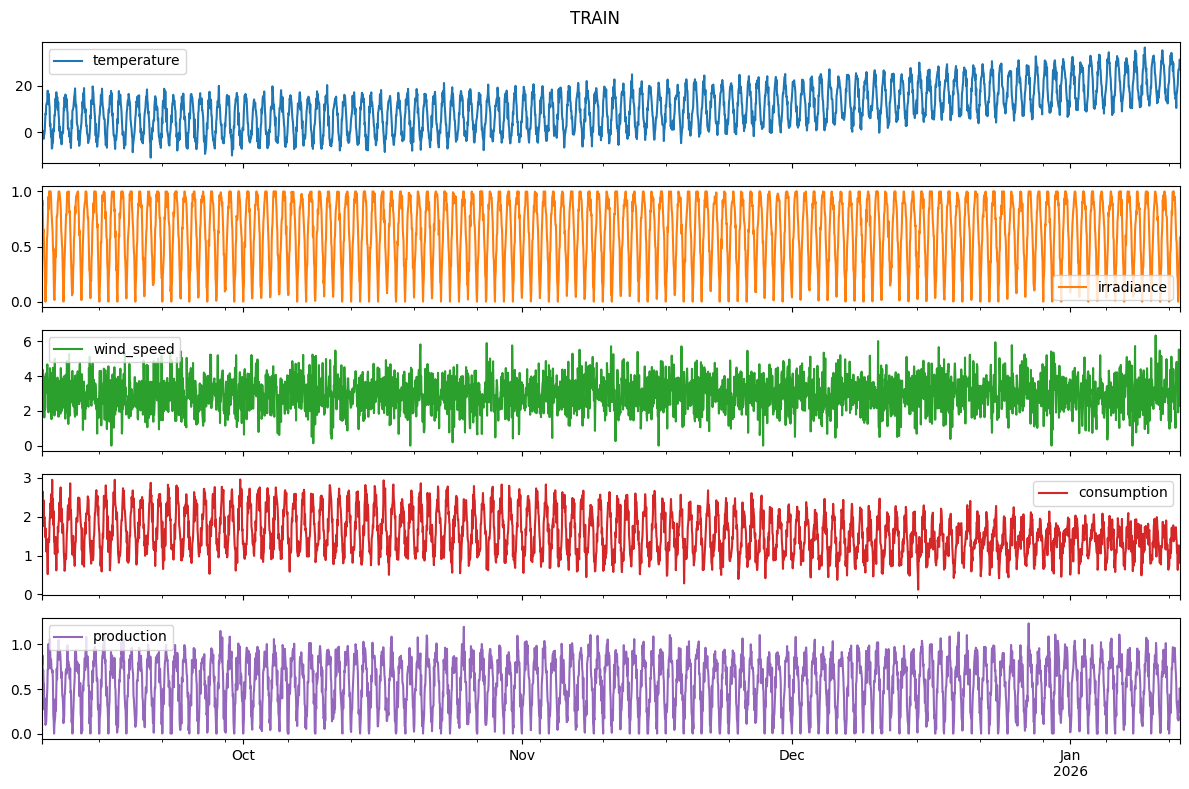

Matrice di correlazione TRAIN:
             temperature  irradiance  wind_speed  consumption  production
temperature     1.000000    0.000727   -0.012392    -0.738078   -0.005981
irradiance      0.000727    1.000000    0.027295     0.417269    0.944500
wind_speed     -0.012392    0.027295    1.000000     0.026363    0.032599
consumption    -0.738078    0.417269    0.026363     1.000000    0.397247
production     -0.005981    0.944500    0.032599     0.397247    1.000000


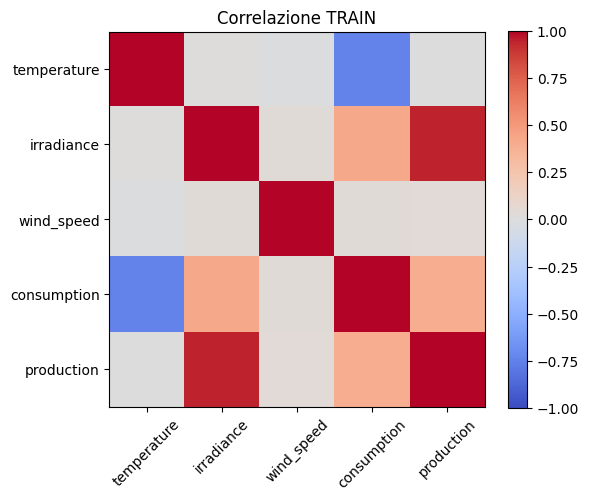

In [21]:
# 4. Analisi statistica
print("Analisi statistica TRAIN...")
analisi_statistica(df_train, title_prefix="TRAIN")

#### 4.2 Analisi statistica VAL

✅ Obiettivo :
- Serve ad avviare un’analisi statistica di riepilogo sui dati di validazione (indicati come df_val), stampando a video statistiche descrittive e grafici.

✅ Descrizione :
- Il codice stampa un messaggio introduttivo ("Analisi statistica VAL...") e poi chiama la funzione analisi_statistica, passando il DataFrame df_val e il prefisso "VAL" per personalizzare titoli e output dell’analisi. 
- La funzione produce statistiche come media, deviazione standard, min/max, e grafici riassuntivi dei dati sul dataset di Validazione come in precedenza fatto sul dataset di TRAIN.
- La funzione inoltre :
  - Visualizza un Grafico delle serie temporali
  - Calcola e stampa della matrice di correlazione
  - Visualizzazione della matrice di correlazione con una heatmap

Analisi statistica VAL...
Statistiche descrittive VAL:
       temperature  irradiance  wind_speed  consumption  production  \
count   652.000000  652.000000  652.000000   652.000000  652.000000   
mean     26.551159    0.634625    3.031821     1.451519    0.570945   
std       7.698599    0.307950    0.997775     0.351432    0.291437   
min       9.392699    0.000000    0.000000     0.408527    0.000000   
25%      19.614988    0.387666    2.376336     1.202222    0.343800   
50%      26.678315    0.720221    3.037080     1.441272    0.611796   
75%      33.350700    0.910324    3.720817     1.709689    0.818506   
max      42.100097    1.000000    5.713686     2.303042    1.137206   

             hour         dow      hour_sin      hour_cos     dow_sin  \
count  652.000000  652.000000  6.520000e+02  6.520000e+02  652.000000   
mean    11.475460    3.082822  5.428003e-03 -2.248352e-03   -0.007195   
std      6.913844    1.972751  7.089117e-01  7.063609e-01    0.714453   
min      0.00

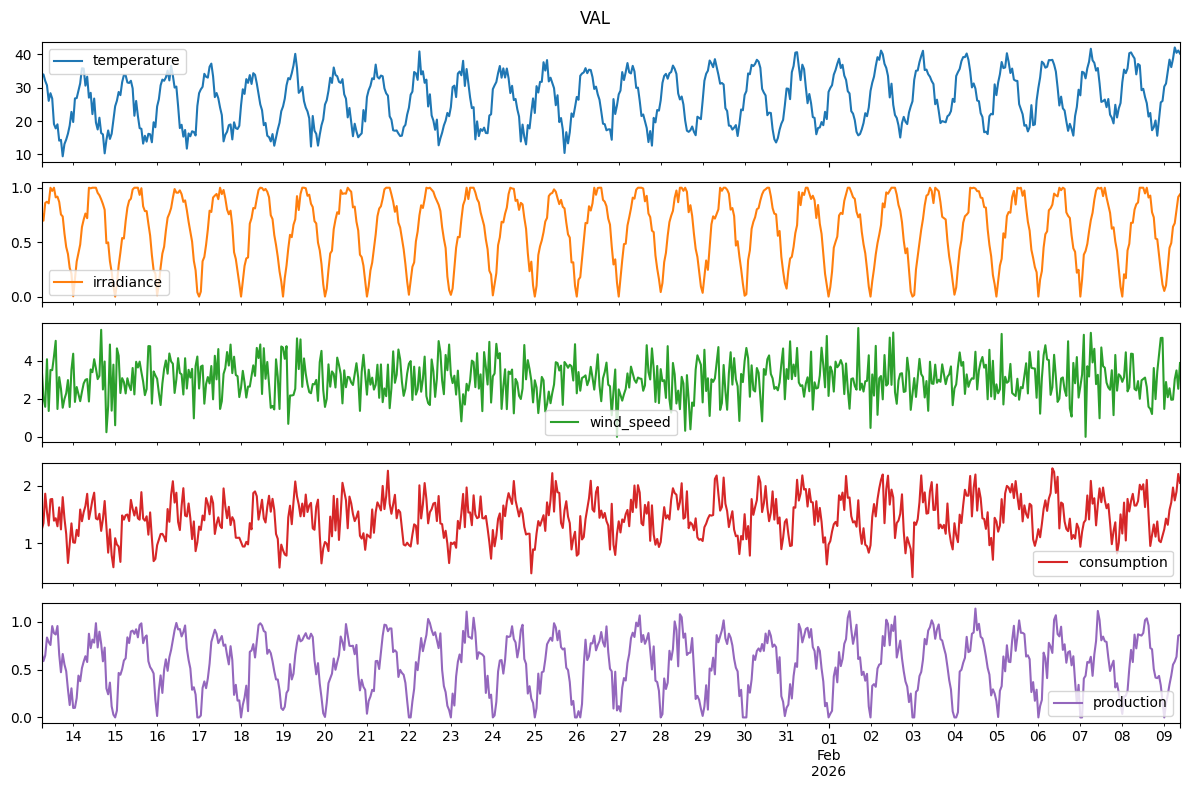

Matrice di correlazione VAL:
             temperature  irradiance  wind_speed  consumption  production
temperature     1.000000    0.002015   -0.022734     0.354040    0.008822
irradiance      0.002015    1.000000   -0.009177     0.666439    0.944864
wind_speed     -0.022734   -0.009177    1.000000     0.028630   -0.016070
consumption     0.354040    0.666439    0.028630     1.000000    0.640176
production      0.008822    0.944864   -0.016070     0.640176    1.000000


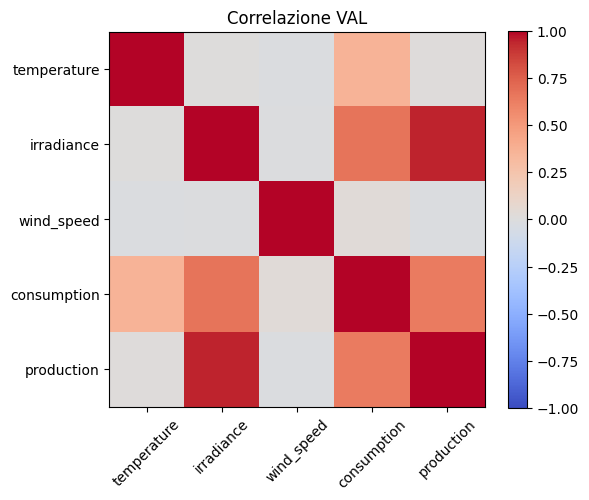

In [22]:
print("Analisi statistica VAL...")
analisi_statistica(df_val, title_prefix="VAL")

#### 4.3 Analisi statistica TEST

✅ Obiettivo :
- Serve ad avviare un’analisi statistica di riepilogo sui dati di Test (indicati come df_val), stampando a video statistiche descrittive e grafici.

✅ Descrizione :
- Il codice stampa un messaggio introduttivo ("Analisi statistica TEST...") e poi chiama la funzione analisi_statistica, passando il DataFrame df_val e il prefisso "TEST" per personalizzare titoli e output dell’analisi. 
- La funzione produce statistiche come media, deviazione standard, min/max, e grafici riassuntivi dei dati sul dataset di Validazione come in precedenza fatto sul dataset di TRAIN.
- La funzione inoltre :
  - Visualizza un Grafico delle serie temporali
  - Calcola e stampa della matrice di correlazione
  - Visualizzazione della matrice di correlazione con una heatmap

Analisi statistica TEST...
Statistiche descrittive TEST:
       temperature  irradiance  wind_speed  consumption  production  \
count   652.000000  652.000000  652.000000   652.000000  652.000000   
mean     31.978954    0.636353    3.048371     1.631959    0.576001   
std       7.604325    0.307744    1.020840     0.384396    0.285747   
min      16.889519    0.000000    0.000000     0.555702    0.000000   
25%      24.996187    0.393300    2.389850     1.327671    0.359865   
50%      31.638392    0.709593    3.042749     1.610992    0.622763   
75%      38.886246    0.919024    3.695478     1.929790    0.806817   
max      47.873429    1.000000    6.678973     2.763072    1.204980   

             hour         dow      hour_sin      hour_cos     dow_sin  \
count  652.000000  652.000000  6.520000e+02  6.520000e+02  652.000000   
mean    11.500000    3.000000  7.668712e-04 -5.824965e-03    0.011991   
std      6.906774    1.962787  7.058931e-01  7.093775e-01    0.711755   
min      0.

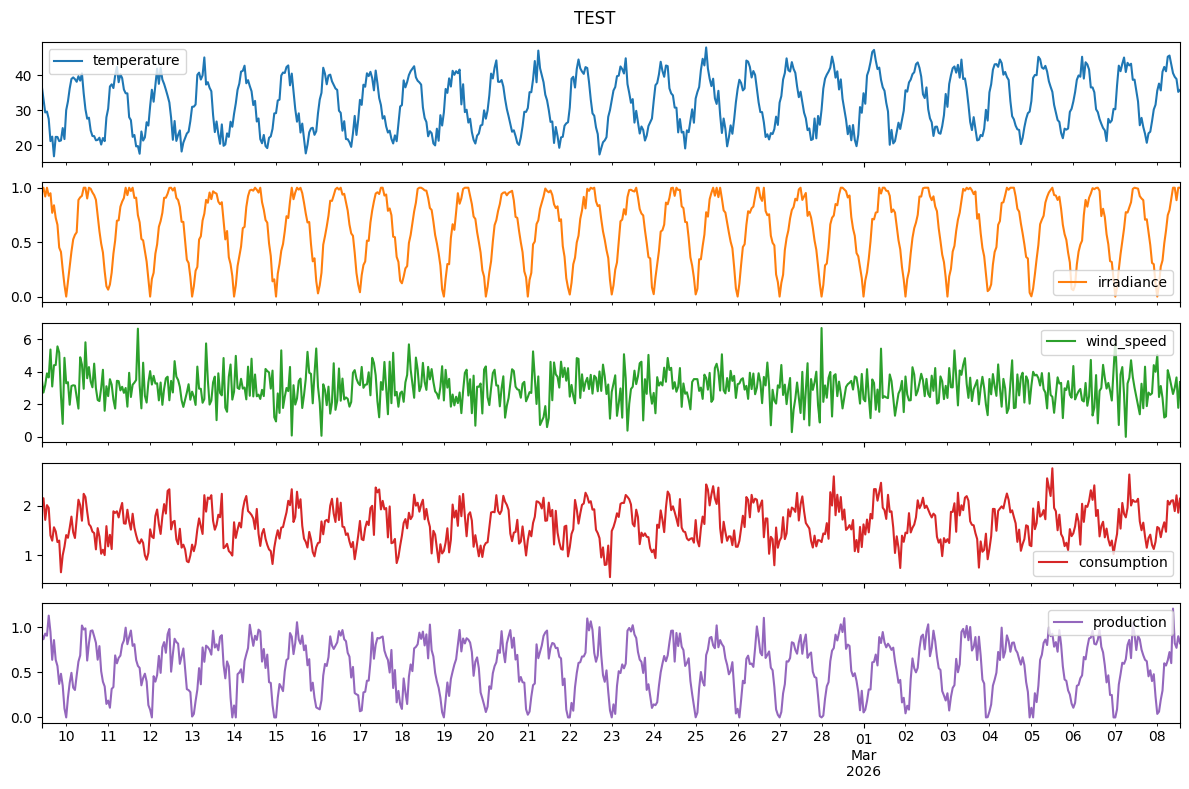

Matrice di correlazione TEST:
             temperature  irradiance  wind_speed  consumption  production
temperature     1.000000    0.009664   -0.059086     0.600141    0.017101
irradiance      0.009664    1.000000   -0.006193     0.581168    0.942479
wind_speed     -0.059086   -0.006193    1.000000    -0.033530   -0.017438
consumption     0.600141    0.581168   -0.033530     1.000000    0.555000
production      0.017101    0.942479   -0.017438     0.555000    1.000000


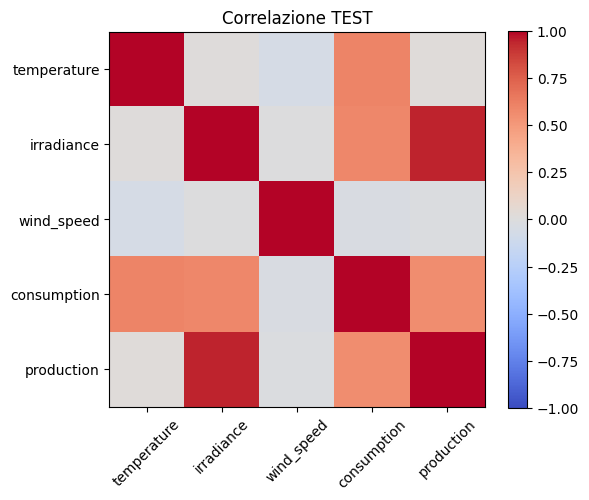

In [23]:
print("Analisi statistica TEST...")
analisi_statistica(df_test, title_prefix="TEST")

### 5. Preparazione dati per i modelli di Produzione e Consumo

In [25]:
# 5. Preparazione dati per modello Produzione e Consumo (con scaling e senza data leakage)
print("Preparazione dati per modelli (scaling, split coerente)...")

# Features encoder per produzione e consumo
df_features_past_prod = pd.concat([
    df_hist[['temperature', 'irradiance', 'wind_speed',
             'hour_sin', 'hour_cos',
             'dow_sin', 'dow_cos']],
    df_hist[['production']]
], axis=1)

df_features_past_cons = pd.concat([
    df_hist[['temperature', 'irradiance', 'wind_speed',
             'hour_sin', 'hour_cos',
             'dow_sin', 'dow_cos',
             'consumption_lag1']],
    df_hist[['consumption']]
], axis=1)

# Metoo storico separato per train/val/test (SOLO storico, senza meteo_future)
meteo_train = meteo_hist.loc[df_train.index]
meteo_val = meteo_hist.loc[df_val.index]
meteo_test = meteo_hist.loc[df_test.index]

# Evitare data leakage: costruire subset di target per ogni fold
df_targets_prod_train = produzione_hist.loc[df_train.index]
df_targets_prod_val = produzione_hist.loc[df_val.index]
df_targets_prod_test = produzione_hist.loc[df_test.index]

df_targets_cons_train = consumo_hist.loc[df_train.index]
df_targets_cons_val = consumo_hist.loc[df_val.index]
df_targets_cons_test = consumo_hist.loc[df_test.index]

# Normalizzazione: fit SOLO su dati di train
scaler_features_prod = StandardScaler()
scaler_features_cons = StandardScaler()

scaler_prod_target = StandardScaler()
scaler_cons_target = StandardScaler()

# *** NUOVO ***
# scaler dedicati solo al meteo (decoder seq2seq)
scaler_meteo_prod = StandardScaler()
scaler_meteo_cons = StandardScaler()

scaler_features_prod.fit(df_features_past_prod.loc[df_train.index].values)
scaler_features_cons.fit(df_features_past_cons.loc[df_train.index].values)

scaler_prod_target.fit(df_targets_prod_train.values.reshape(-1, 1))
scaler_cons_target.fit(df_targets_cons_train.values.reshape(-1, 1))

# *** NUOVO ***
# fit degli scaler meteo SOLO su train
scaler_meteo_prod.fit(meteo_train.values)
scaler_meteo_cons.fit(meteo_train.values)

# Applicare scaling (transform) alle serie mantenendo indici/colonne
df_features_past_prod_scaled = pd.DataFrame(
    scaler_features_prod.transform(df_features_past_prod.values),
    index=df_features_past_prod.index,
    columns=df_features_past_prod.columns
)

df_features_past_cons_scaled = pd.DataFrame(
    scaler_features_cons.transform(df_features_past_cons.values),
    index=df_features_past_cons.index,
    columns=df_features_past_cons.columns
)

produzione_hist_scaled = pd.Series(
    scaler_prod_target.transform(produzione_hist.values.reshape(-1,1)).flatten(),
    index=produzione_hist.index,
    name='production'
)

consumo_hist_scaled = pd.Series(
    scaler_cons_target.transform(consumo_hist.values.reshape(-1,1)).flatten(),
    index=consumo_hist.index,
    name='consumption'
)

# ==============================
# METEO SCALATO PER DECODER
# ==============================

meteo_hist_scaled_prod = pd.DataFrame(
    scaler_meteo_prod.transform(df_hist[['temperature','irradiance','wind_speed']].values),
    index=df_hist.index,
    columns=['temperature','irradiance','wind_speed']
)

meteo_hist_scaled_cons = pd.DataFrame(
    scaler_meteo_cons.transform(df_hist[['temperature','irradiance','wind_speed']].values),
    index=df_hist.index,
    columns=['temperature','irradiance','wind_speed']
)

meteo_train_scaled_prod = meteo_hist_scaled_prod.loc[meteo_train.index]
meteo_val_scaled_prod = meteo_hist_scaled_prod.loc[meteo_val.index]
meteo_test_scaled_prod = meteo_hist_scaled_prod.loc[meteo_test.index]

meteo_train_scaled_cons = meteo_hist_scaled_cons.loc[meteo_train.index]
meteo_val_scaled_cons = meteo_hist_scaled_cons.loc[meteo_val.index]
meteo_test_scaled_cons = meteo_hist_scaled_cons.loc[meteo_test.index]

# ==============================
# Creazione sequence dataset - Consumo
# ==============================

df_targets_cons_val_scaled = pd.Series(
    scaler_cons_target.transform(
        df_targets_cons_val.values.reshape(-1, 1)
    ).flatten(),
    index=df_targets_cons_val.index
)

df_targets_cons_test_scaled = pd.Series(
    scaler_cons_target.transform(
        df_targets_cons_test.values.reshape(-1, 1)
    ).flatten(),
    index=df_targets_cons_test.index
)

# TRAIN
X_enc_train_c, X_dec_train_c, y_train_c = crea_sequence_dataset(
    df_features_past_cons_scaled.loc[df_train.index],
    df_train[['consumption']],
    meteo_train_scaled_cons,
    consumo_hist_scaled,
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)

# VALIDATION
X_enc_val_c, X_dec_val_c, y_val_c = crea_sequence_dataset(
    df_features_past_cons_scaled.loc[df_val.index],
    df_val[['consumption']],
    meteo_val_scaled_cons,
    df_targets_cons_val_scaled,
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)

# TEST
X_enc_test_c, X_dec_test_c, y_test_c = crea_sequence_dataset(
    df_features_past_cons_scaled.loc[df_test.index],
    df_test[['consumption']],
    meteo_test_scaled_cons,
    df_targets_cons_test_scaled,
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)
# ==============================
# Creazione sequence dataset - Produzione
# ==============================

# *** NUOVO ***
# scaling target produzione anche per val/test (prima mancava)
df_targets_prod_val_scaled = pd.Series(
    scaler_prod_target.transform(df_targets_prod_val.values.reshape(-1,1)).flatten(),
    index=df_targets_prod_val.index
)

df_targets_prod_test_scaled = pd.Series(
    scaler_prod_target.transform(df_targets_prod_test.values.reshape(-1,1)).flatten(),
    index=df_targets_prod_test.index
)

X_enc_train_p, X_dec_train_p, y_train_p = crea_sequence_dataset(
    df_features_past_prod_scaled.loc[df_train.index],
    df_train[['production']],
    meteo_train_scaled_prod,
    produzione_hist_scaled,
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)

X_enc_val_p, X_dec_val_p, y_val_p = crea_sequence_dataset(
    df_features_past_prod_scaled.loc[df_val.index],
    df_val[['production']],
    meteo_val_scaled_prod,
    df_targets_prod_val_scaled,   # *** MODIFICATO ***
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)

X_enc_test_p, X_dec_test_p, y_test_p = crea_sequence_dataset(
    df_features_past_prod_scaled.loc[df_test.index],
    df_test[['production']],
    meteo_test_scaled_prod,
    df_targets_prod_test_scaled,  # *** MODIFICATO ***
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)

# Funzione di validazione shape
def validate_shapes(X_enc, X_dec, y, expected_enc_features, expected_dec_features, expected_past_window=PAST_WINDOW, expected_future_window=FUTURE_WINDOW):
    assert X_enc.ndim == 3, f"X_enc deve essere 3D, trovato {X_enc.ndim}D"
    assert X_dec.ndim == 3, f"X_dec deve essere 3D, trovato {X_dec.ndim}D"
    assert y.ndim in (2,3), f"y deve essere 2D/3D, trovato {y.ndim}D"
    assert X_enc.shape[1] == expected_past_window
    assert X_dec.shape[1] == expected_future_window
    assert X_enc.shape[2] == expected_enc_features
    assert X_dec.shape[2] == expected_dec_features
    assert not np.isnan(X_enc).any()
    assert not np.isnan(X_dec).any()
    assert not np.isnan(y).any()
    assert X_enc.shape[0] == y.shape[0]
    assert X_dec.shape[0] == y.shape[0]

    print(f"✅ Shape validation passed: X_enc={X_enc.shape}, X_dec={X_dec.shape}, y={y.shape}")

# Eseguire le validazioni minime
n_features_enc = df_features_past_cons_scaled.shape[1]
n_features_dec = meteo_train_scaled_cons.shape[1]

validate_shapes(X_enc_train_c, X_dec_train_c, y_train_c, n_features_enc, n_features_dec)

n_features_enc_p = df_features_past_prod_scaled.shape[1]
n_features_dec_p = meteo_train_scaled_prod.shape[1]

validate_shapes(X_enc_train_p, X_dec_train_p, y_train_p, n_features_enc_p, n_features_dec_p)

print("Preparazione completata.")

Preparazione dati per modelli (scaling, split coerente)...
✅ Shape validation passed: X_enc=(2538, 336, 9), X_dec=(2538, 168, 3), y=(2538, 168)
✅ Shape validation passed: X_enc=(2538, 336, 8), X_dec=(2538, 168, 3), y=(2538, 168)
Preparazione completata.


### 6. Costruzione e addestramento modello dei Consumi

In [26]:
# 6. Costruzione e addestramento modello dei Consumi
print("Costruzione modello seq2seq... (esempio generico)")
print("Modello dei Consumi")
n_features_enc = df_features_past_cons_scaled.shape[1]
n_features_dec = meteo_train_scaled_cons.shape[1]

# Costruzione modello consumo
model_cons = build_seq2seq_model(n_features_enc=n_features_enc, n_features_dec=n_features_dec)
print("***********  ADDESTRAMENTO MODELLO CONSUMI ************")
# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

history_cons = model_cons.fit(
    [X_enc_train_c, X_dec_train_c],
    y_train_c,
    epochs=30,
    batch_size=32,
    validation_data=([X_enc_val_c, X_dec_val_c], y_val_c),
    callbacks=[early_stop],
)

print(model_cons.summary())
# ===== Salvataggio modello e history =====
# models_dir = Path('models')
models_dir = Path().resolve() / "models"
models_dir.mkdir(exist_ok=True)
timestamp = dt.now().strftime('%Y%m%d_%H%M%S')
model_cons_path = models_dir / f"model_consumption_{timestamp}.h5"
model_cons.save(str(model_cons_path))
history_cons_path = models_dir / f"history_consumption_{timestamp}.json"
with open(history_cons_path, 'w') as f:
    json.dump({k:[float(x) for x in v] for k,v in history_cons.history.items()}, f, indent=2)
print(f"💾 Modello consumo salvato: {model_cons_path}")

Costruzione modello seq2seq... (esempio generico)
Modello dei Consumi
***********  ADDESTRAMENTO MODELLO CONSUMI ************
Epoch 1/30
80/80 [==============================] - 49s 514ms/step - loss: 0.2795 - val_loss: 0.5039
Epoch 2/30
80/80 [==============================] - 38s 479ms/step - loss: 0.1688 - val_loss: 0.2614
Epoch 3/30
80/80 [==============================] - 39s 487ms/step - loss: 0.1604 - val_loss: 0.2146
Epoch 4/30
80/80 [==============================] - 39s 486ms/step - loss: 0.1561 - val_loss: 0.2608
Epoch 5/30
80/80 [==============================] - 39s 490ms/step - loss: 0.1529 - val_loss: 0.5057
Epoch 6/30
80/80 [==============================] - 40s 502ms/step - loss: 0.1503 - val_loss: 0.4341
Epoch 7/30
80/80 [==============================] - 40s 501ms/step - loss: 0.1475 - val_loss: 0.4030
Epoch 8/30
80/80 [==============================] - 38s 476ms/step - loss: 0.1449 - val_loss: 0.3874
Epoch 9/30
80/80 [==============================] - 38s 473ms/step

c:\Users\Maurizio\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


💾 Modello consumo salvato: F:\02. EMSFS\12 - AI\Corsi AI on-line\Sezione 30 - Specifiche tematiche\40. E&U\21. Fabbisogno Energetico\models\model_consumption_20260308_135903.h5


### 7. Costruzione e addestramento modello delle Produzioni

In [27]:
print("Modello delle Produzioni")
n_features_enc_prod = df_features_past_prod_scaled.shape[1]
n_features_dec_prod = meteo_train_scaled_prod.shape[1]

model_prod = build_seq2seq_model(n_features_enc=n_features_enc_prod, n_features_dec=n_features_dec_prod)

print("***********  ADDESTRAMENTO MODELLO PRODUZIONE ************")
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_prod = model_prod.fit(
    [X_enc_train_p, X_dec_train_p],
    y_train_p,
    epochs=30,
    batch_size=32,
    validation_data=([X_enc_val_p, X_dec_val_p], y_val_p),
    callbacks=[early_stop],
)
print(model_prod.summary())
# ===== Salvataggio modello e history =====
# models_dir = Path('models')
models_dir = Path().resolve() / "models"
models_dir.mkdir(exist_ok=True)
timestamp = dt.now().strftime('%Y%m%d_%H%M%S')
model_prod_path = models_dir / f"model_production_{timestamp}.h5"
model_prod.save(str(model_prod_path))
history_prod_path = models_dir / f"history_production_{timestamp}.json"
with open(history_prod_path, 'w') as f:
    json.dump({k:[float(x) for x in v] for k,v in history_prod.history.items()}, f, indent=2)
print(f"💾 Modello produzione salvato: {model_prod_path}")

Modello delle Produzioni
***********  ADDESTRAMENTO MODELLO PRODUZIONE ************
Epoch 1/30
80/80 [==============================] - 45s 475ms/step - loss: 0.3110 - val_loss: 0.2232
Epoch 2/30
80/80 [==============================] - 37s 463ms/step - loss: 0.1436 - val_loss: 0.2162
Epoch 3/30
80/80 [==============================] - 37s 469ms/step - loss: 0.1392 - val_loss: 0.2046
Epoch 4/30
80/80 [==============================] - 37s 468ms/step - loss: 0.1364 - val_loss: 0.1883
Epoch 5/30
80/80 [==============================] - 38s 475ms/step - loss: 0.1342 - val_loss: 0.1924
Epoch 6/30
80/80 [==============================] - 38s 473ms/step - loss: 0.1324 - val_loss: 0.1797
Epoch 7/30
80/80 [==============================] - 38s 474ms/step - loss: 0.1308 - val_loss: 0.1773
Epoch 8/30
80/80 [==============================] - 38s 471ms/step - loss: 0.1291 - val_loss: 0.1731
Epoch 9/30
80/80 [==============================] - 40s 500ms/step - loss: 0.1273 - val_loss: 0.1775
Epoch 1

### 8. Valutazione dei modelli di Consumo e Produzione

In [28]:
# Valutazione su TRAIN - Modello Consumo
y_pred_train_c = model_cons.predict([X_enc_train_c, X_dec_train_c])
mae_c, rmse_c = valuta_metriche(y_train_c, y_pred_train_c)
print(f"✅ Metriche modello Consumo: MAE = {mae_c:.4f}, RMSE = {rmse_c:.4f}")

# Valutazione su TRAIN - Modello Produzione
y_pred_train_p = model_prod.predict([X_enc_train_p, X_dec_train_p])
mae_p, rmse_p = valuta_metriche(y_train_p, y_pred_train_p)
print(f"✅ Metriche modello Produzione: MAE = {mae_p:.4f}, RMSE = {rmse_p:.4f}")

# Valutazione su TEST - Modello Consumo
y_pred_test_c = model_cons.predict([X_enc_test_c, X_dec_test_c])
mae_test_c, rmse_test_c = valuta_metriche(y_test_c, y_pred_test_c)
print(f"✅ Test Consumo: MAE = {mae_test_c:.4f}, RMSE = {rmse_test_c:.4f}")

# Valutazione su TEST - Modello Produzione
y_pred_test_p = model_prod.predict([X_enc_test_p, X_dec_test_p])
mae_test_p, rmse_test_p = valuta_metriche(y_test_p, y_pred_test_p)
print(f"✅ Test Produzione: MAE = {mae_test_p:.4f}, RMSE = {rmse_test_p:.4f}")

80/80 [==============================] - 17s 186ms/step
✅ Metriche modello Consumo: MAE = 0.3055, RMSE = 0.3857
80/80 [==============================] - 19s 212ms/step
✅ Metriche modello Produzione: MAE = 0.2763, RMSE = 0.3496
5/5 [==============================] - 2s 290ms/step
✅ Test Consumo: MAE = 0.4030, RMSE = 0.5169
5/5 [==============================] - 2s 273ms/step
✅ Test Produzione: MAE = 0.3358, RMSE = 0.4052


#### Commento di ChatGPT

Le metriche che riporti sono coerenti e abbastanza buone, ma raccontano alcune cose importanti sul comportamento dei due modelli (consumo e produzione). Analizziamole con ordine

✅ Risultati ottenuti

1️⃣ Confronto Training vs Test

        Consumo                                 Produzione

| fase     | MAE    | RMSE   |          | fase     | MAE    | RMSE   |
| -------- | ------ | ------ |          | -------- | ------ | ------ |        
| training | 0.3055 | 0.3857 |          | training | 0.2763 | 0.3496 |
| test     | 0.4030 | 0.5169 |          | test     | 0.3358 | 0.4052 |

2️⃣ Gap training → test

Calcoliamo il degrado percentuale.			
        Consumo		                            Produzione	
MAE:	(0.4030−0.3055)/0.3055≈31.9%	MAE:	(0.3358−0.2763)/0.2763≈21.5%
RMSE	(0.5169−0.3857)/0.3857≈34%	    RMSE	(0.4052−0.3496)/0.3496≈15.9%

3️⃣ Interpretazione

#### Produzione

- Il modello di produzione è più stabile.

- Motivo probabile:  production ≈ f(irradiance, temperature, hour)

- cioè variabili fisicamente deterministiche.

Quindi:

- meno rumore
- meno dinamica autoregressiva
- previsione più facile

#### Consumo

Il consumo è più difficile da prevedere. Dipende da:

- meteo
- giorno settimana
- ora
- comportamento umano
- processi industriali
- eventi casuali

Quindi:

- più rumore
- più non linearità
- più dipendenza dal passato

Il gap del 30-34% è normale nei modelli energetici

4️⃣ MAE vs RMSE

Un dettaglio interessante:

Consumo
RMSE / MAE ≈ 1.28
Produzione
RMSE / MAE ≈ 1.21

Questo indica:

- nel consumo ci sono più outlier 
- errori occasionalmente più grandi

tipico dei carichi energetici.

5️⃣ Giudizio complessivo

- modello  produzione :  molto buono        
- modello  consumo	:   buono ma migliorabile

Per un modello seq2seq con: 336 ore encoder, 168 ore decoder sono metriche realistiche.

### Calcolo e visualizzazione delle Loss Function sui dataset TRAIN e VAL (Consumo e Produzione)

✅ Obiettivo:
- Questo codice serve a visualizzare l’andamento della funzione di perdita (loss) durante l’addestramento e la validazione di due modelli predittivi: uno per il consumo e uno per la produzione di energia FV.

✅ Descrizione:
- Definisce la funzione plot_loss, che crea un grafico a linee dell'evoluzione dell’errore (loss) per ogni epoca di addestramento, sia sui dati di training (loss) sia su quelli di validazione (val_loss). La funzione viene poi chiamata due volte:
  - una per tracciare il comportamento della loss del **modello di consumo (history_cons)**,
  - una per il **modello di produzione (history_prod)**.
- Il grafico aiuta a valutare se il modello sta imparando correttamente o sta overfittando.

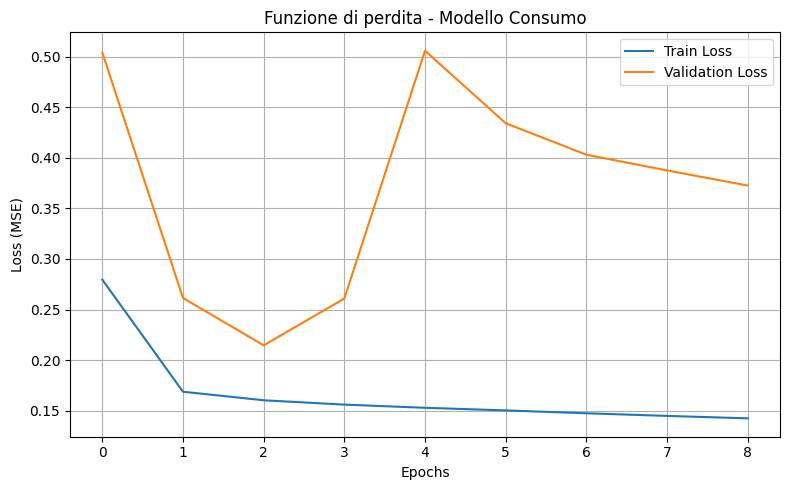

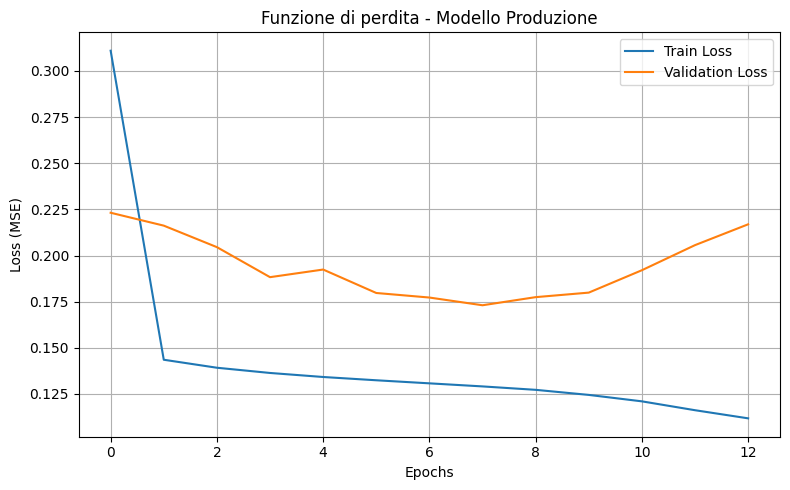

In [29]:
# Calcolo e visualizzazione delle Loss Function sui dataset TRAIN e VAL (Consumo e Produzione)
def plot_loss(history, title):
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot per modello consumo
plot_loss(history_cons, "Funzione di perdita - Modello Consumo")

# Plot per modello produzione
plot_loss(history_prod, "Funzione di perdita - Modello Produzione")

### Elaborazione grafici diagnostici Consumi Reali/Predetti.

Verrano elaborati tre tipologie di grafico. La struttura è la seguente :

- 1️⃣ Routine preparazione dati per i grafici
  - Questa trasforma le finestre (n_samples, horizon) in una serie unica.
- 2️⃣ Grafico andamento reale vs predetto
  - Questo è il grafico che fa capire se il modello segue davvero la dinamica dei consumi.
- 3️⃣ Grafico scatter diagnostico
  - Questo è uno dei grafici più usati nel forecasting.

In [30]:
def prepara_dati_grafici(y_true, y_pred):
    import numpy as np
    
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    
    return y_true_flat, y_pred_flat

def plot_scatter_reale_predetto(y_true_flat, y_pred_flat):

    import matplotlib.pyplot as plt
    import numpy as np

    plt.figure(figsize=(6,6))

    plt.scatter(y_true_flat, y_pred_flat, alpha=0.3)

    plt.xlabel("Consumo reale")
    plt.ylabel("Consumo predetto")

    plt.title("Scatter reale vs predetto - modello consumo")

    min_val = min(y_true_flat.min(), y_pred_flat.min())
    max_val = max(y_true_flat.max(), y_pred_flat.max())

    plt.plot([min_val, max_val], [min_val, max_val])

    plt.grid(True)
    plt.tight_layout()

    plt.show()

def plot_andamento_consumo(y_true_flat, y_pred_flat):

    import matplotlib.pyplot as plt

    plt.figure(figsize=(14,5))

    plt.plot(y_true_flat, label="Consumo reale", alpha=0.8)
    plt.plot(y_pred_flat, label="Consumo predetto", alpha=0.8)

    plt.title("Consumo reale vs predetto (test set completo)")
    plt.xlabel("Time step")
    plt.ylabel("Consumo")

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()
    
def plot_errori_consumo(y_true_flat, y_pred_flat):

    import matplotlib.pyplot as plt
    import numpy as np

    errors = y_true_flat - y_pred_flat

    plt.figure(figsize=(14,4))

    plt.plot(errors)

    plt.title("Errore modello consumo")
    plt.xlabel("Time step")
    plt.ylabel("Errore")

    plt.grid(True)
    plt.tight_layout()

    plt.show()

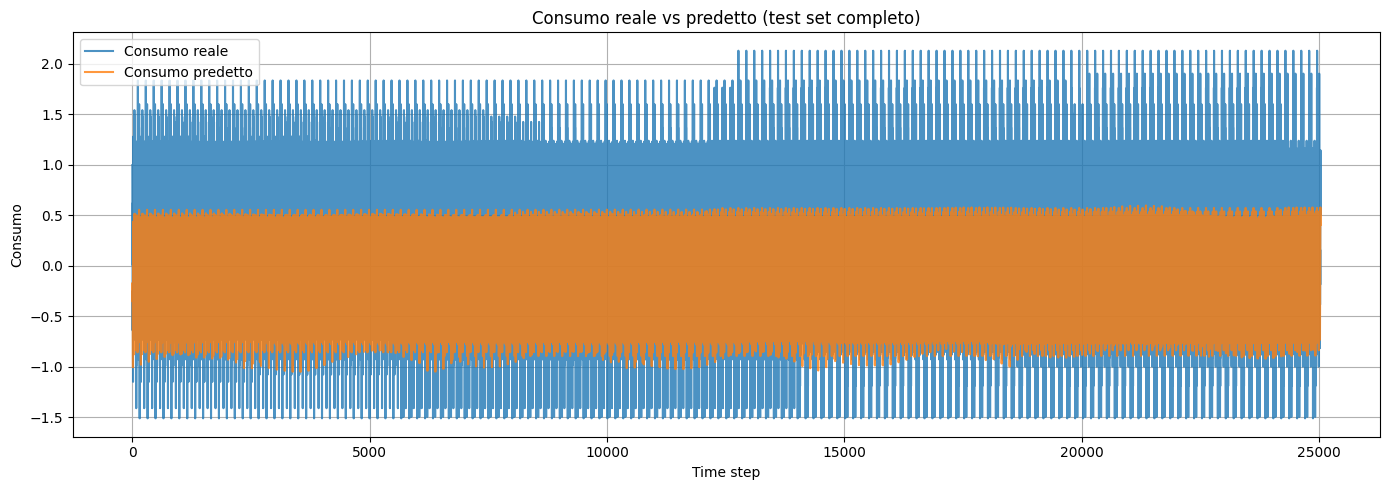

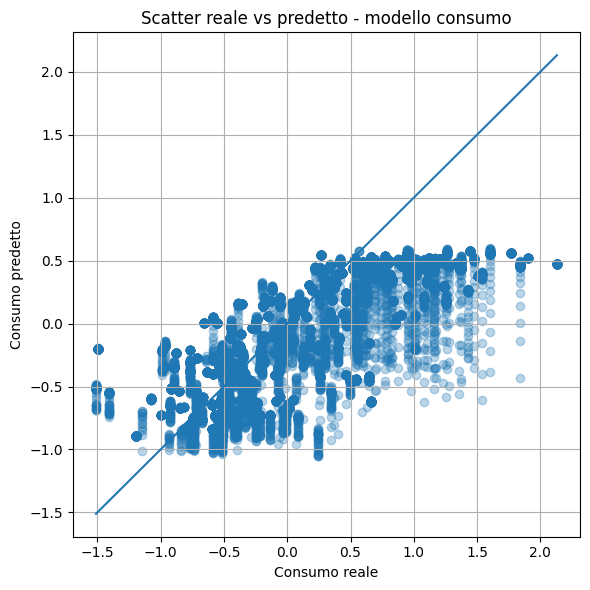

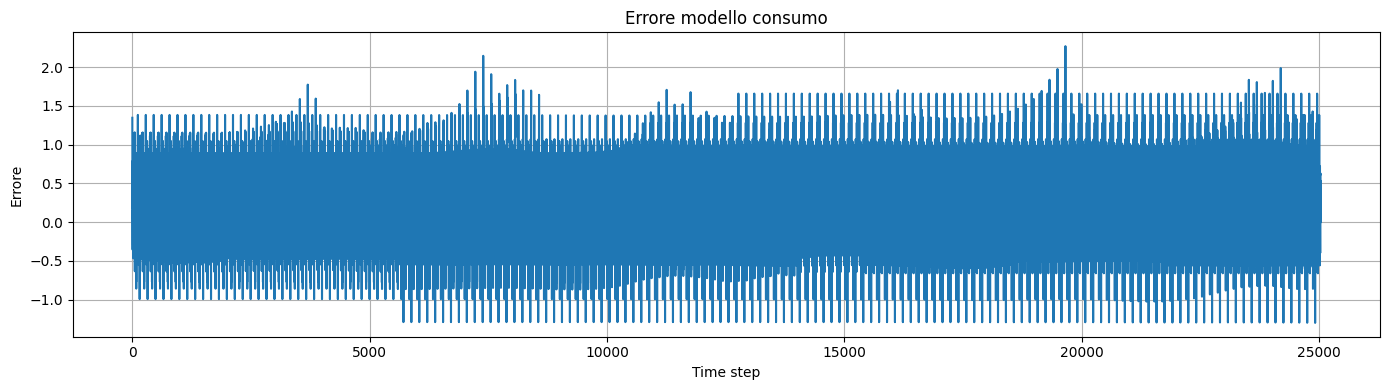

In [32]:
# ================================
# ANALISI GRAFICA MODELLO CONSUMO
# ================================

y_true_flat, y_pred_flat = prepara_dati_grafici(y_test_c, y_pred_test_c)

plot_andamento_consumo(y_true_flat, y_pred_flat)
plot_scatter_reale_predetto(y_true_flat, y_pred_flat)
plot_errori_consumo(y_true_flat, y_pred_flat)

### Visualizza Grafico comparativo tra Consumo Reale e Predetto (finestra)

✅ Obiettivo:
- Serve a confrontare visivamente i valori reali e quelli predetti da un modello su una finestra temporale specifica, utile per valutare la qualità della previsione su brevi intervalli.

✅ Descrizione della Funzione:
- La funzione plot_confronto_window riceve due array (valori reali e predetti) suddivisi in finestre (es. sequenze orarie), seleziona la finestra di indice window_idx, e ne traccia i dati in un grafico a linee. I valori reali e predetti vengono confrontati passo-passo nel tempo (es. ora per ora), con simboli diversi per facilitarne il confronto.
Il codice infine esegue due confronti. Nel nostro caso:
  - uno per la seconda finestra (window_idx=1) del modello di consumo,
  - uno per la seconda finestra (window_idx=1) del modello di produzione.

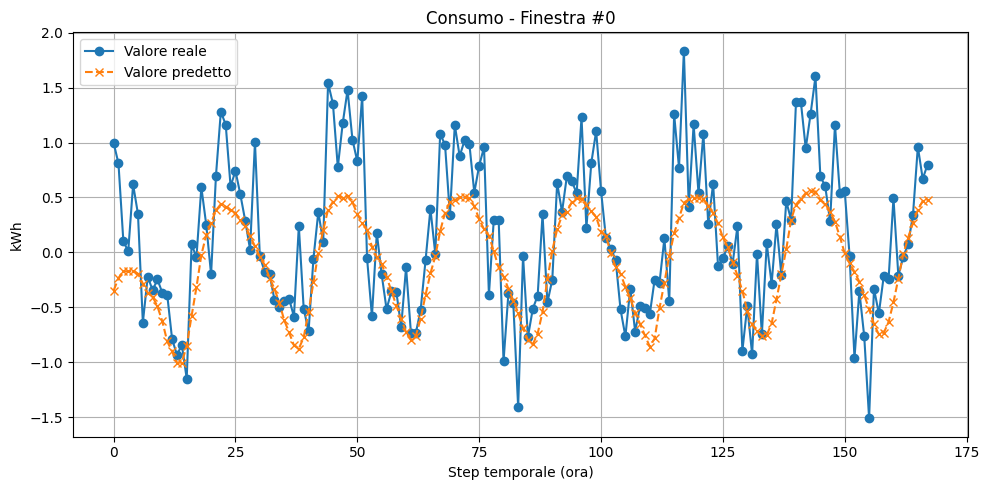

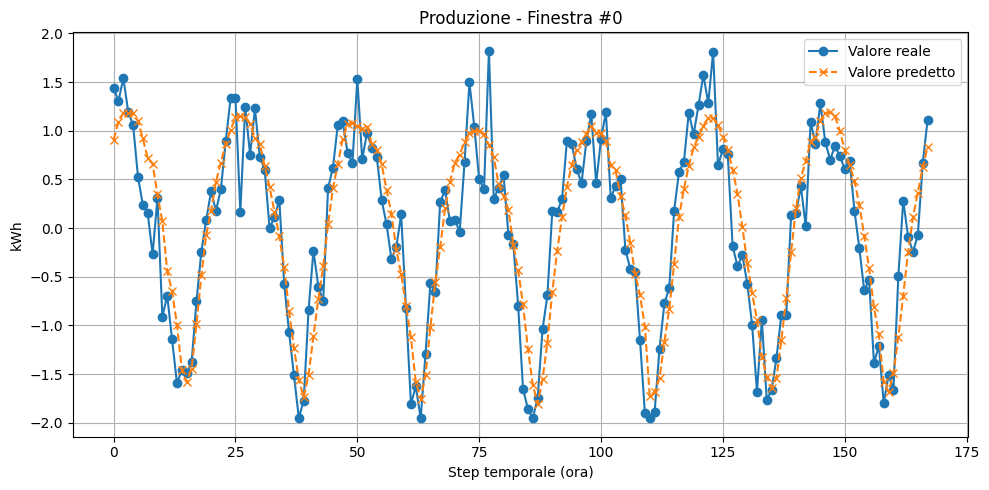

In [33]:
# Visualizza Grafico comparativo tra Consumo Reale e Predetto (finestra)
def plot_confronto_window(y_true, y_pred, window_idx=0, title_prefix=""):
    if window_idx >= len(y_true):
        print("❌ Errore: indice fuori range.")
        return

    true_vals = y_true[window_idx].flatten()
    pred_vals = y_pred[window_idx].flatten()

    plt.figure(figsize=(10, 5))
    plt.plot(true_vals, label='Valore reale', marker='o', linestyle='-')
    plt.plot(pred_vals, label='Valore predetto', marker='x', linestyle='--')
    plt.title(f"{title_prefix} - Finestra #{window_idx}")
    plt.xlabel("Step temporale (ora)")
    plt.ylabel("kWh")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
plot_confronto_window(y_test_c, y_pred_test_c, window_idx=0, title_prefix="Consumo")
plot_confronto_window(y_test_p, y_pred_test_p, window_idx=0, title_prefix="Produzione")

### Visualizza Grafico comparativo tra Consumo Reale e Predetto (intero periodo di analisi)

✅ Obiettivo:
- Serve a visualizzare la distribuzione degli errori di previsione, ovvero la differenza tra valori reali e valori predetti, per valutare la qualità e il comportamento del modello.

✅ Descrizione della Funzione:
- La funzione plot_error_distribution calcola gli errori come differenza tra y_true e y_pred, li appiattisce in un array monodimensionale, e ne disegna l’istogramma con curva di densità stimata (KDE) per analizzarne la distribuzione.
- Viene poi tracciata una linea verticale in corrispondenza dello zero (errore nullo) per facilitare il confronto tra sovra- e sotto-predizioni.
La funzione viene eseguita due volte:
  - per analizzare la distribuzione degli errori del modello di consumo (y_test_c vs y_pred_test_c),
  - per quella del modello di produzione (y_test_p vs y_pred_test_p).

✅ Descrizione tipo di grafico:

- È un istogramma che mostra la frequenza degli errori commessi dal modello nel predire i valori rispetto ai dati reali. È molto utile per capire quanto e come il modello sbaglia.
- L'errore per ciascun punto è calcolato come:
  - errore=valore reale−valore predetto
- Quindi:
  - **Errore = 0**: il modello ha predetto esattamente il valore reale.
  - **Errore > 0 (a sinistra dello 0)**: il modello ha sottostimato il valore reale → ha previsto meno di quanto accaduto.
  - **Errore < 0 (a destra dello 0)**: il modello ha sovrastimato il valore reale → ha previsto più di quanto accaduto.
- L'asse X mostra l'intervallo di errore in unità di misura (nel tuo caso, kWh). Esempi:
  - -2 kWh: il modello ha predetto 2 kWh in più rispetto al reale.
  - +3 kWh: il modello ha predetto 3 kWh in meno rispetto al reale.
- L'asse Y mostra quante volte (cioè con che frequenza) si è verificato un certo errore. In altre parole, quanti esempi rientrano in ciascun intervallo di errore.
- linea spezzata sopra l’istogramma è una **KDE (Kernel Density Estimate)**, cioè una stima della densità di probabilità degli errori. Funziona così:
  - "Liscia" l'istogramma per mostrare una curva continua.
  - Aiuta a capire la forma della distribuzione:
    - **Se è simmetrica** → errori bilanciati.
    - **Se è spostata a sinistra/destra** → tendenza del modello a sottostimare o sovrastimare.
    - **Se è "larga"** → gli errori sono molto variabili (scarsa precisione).
    - **Se è "stretta e centrata su 0"** → il modello è preciso e accurato.
- La linea verticale nera tratteggiata su x = 0 è un riferimento che rappresenta l’errore nullo. Serve per valutare visivamente:
  - quanto la distribuzione degli errori sia centrata sullo zero,
  - se il modello tende a sbagliare sistematicamente (bias).

✅ In sintesi, il grafico serve a capire:
- Quanto spesso il modello sbaglia.
- Se tende a sottostimare o sovrastimare.
- Se gli errori sono distribuiti simmetricamente.
- Quanto sono gravi o contenuti gli errori

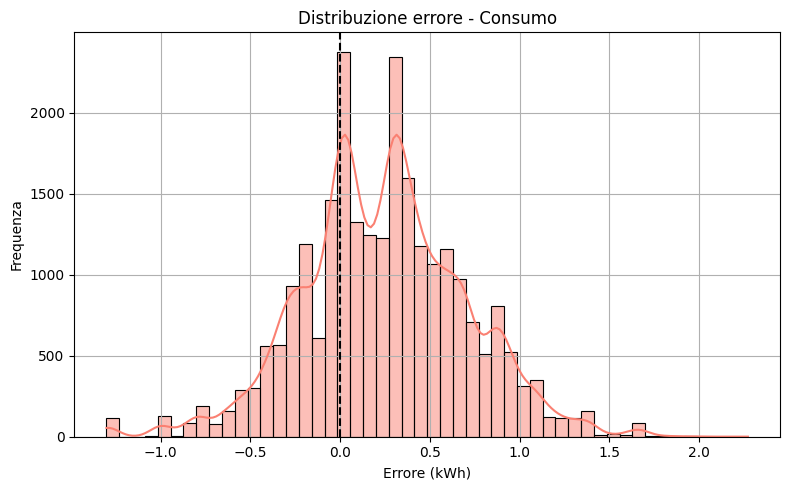

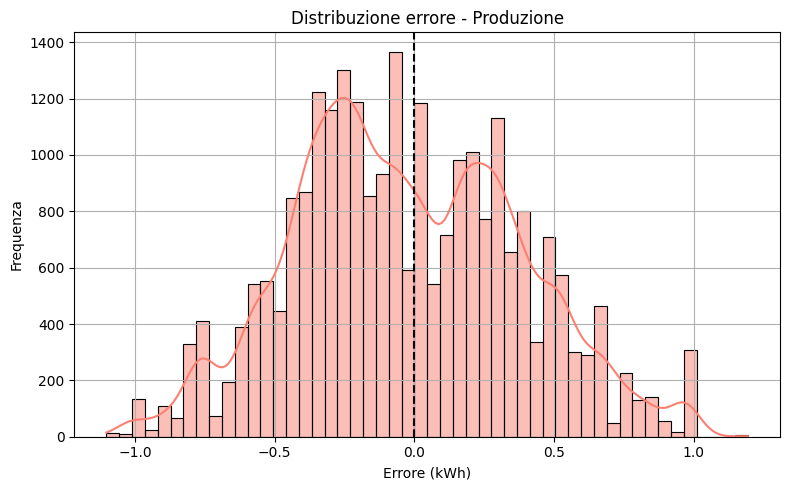

In [34]:
# Visualizza Grafico comparativo tra Consumo Reale e Predetto (intero periodo di analisi)
def plot_error_distribution(y_true, y_pred, title="Distribuzione errore", bins=50):
    errors = y_true.flatten() - y_pred.flatten()

    plt.figure(figsize=(8, 5))
    sns.histplot(errors, bins=bins, kde=True, color='salmon')
    plt.axvline(0, color='black', linestyle='--')
    plt.title(title)
    plt.xlabel("Errore (kWh)")
    plt.ylabel("Frequenza")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
plot_error_distribution(y_test_c, y_pred_test_c, title="Distribuzione errore - Consumo")
plot_error_distribution(y_test_p, y_pred_test_p, title="Distribuzione errore - Produzione")

### 8. Previsione sui prossimi 7 giorni (placeholder esemplificativo)

✅ **Obiettivo**:
- Questo blocco esegue una previsione oraria dei consumi e della produzione di energia per i prossimi 7 giorni, utilizzando i modelli LSTM precedentemente addestrati. È una fase di forecast vera e propria, distinta dall’addestramento e dalla validazione.

✅ **Descrizione**:
- 1. **Previsione dei consumi futuri (forecasted_consumption):**
  - Estrae gli ultimi 7 giorni di dati storici (PAST_WINDOW) come input per l’encoder.
  - Usa le previsioni meteo future come input per il decoder.
  - Passa questi input al modello LSTM (model_cons) per ottenere le previsioni orarie del consumo futuro.
- 2. **Previsione della produzione da fotovoltaico (forecasted_production):**
  - Stesso schema, ma applicato al modello per la produzione (model_prod), con input storici e previsioni meteo.
  - Ottiene la previsione della produzione futura.
- 3. **Crea un DataFrame (df_forecast)**:
  - Combina i risultati in un’unica tabella con indice orario (timestamp).
  - Colonne: consumo previsto, produzione prevista.
- 4. **Stampa un estratto dei risultati per verificarne l’avvenuta generazione.**
  - 5. **Gestione degli errori**:
  - L’intero blocco è dentro un try-except, quindi eventuali problemi nella previsione (es. modelli non definiti o shape errati) vengono catturati e segnalati chiaramente.

✅ **In sintesi**
- Questo blocco è il cuore della previsione futura su 7 giorni:
  - usa gli input meteo previsti e i dati storici per stimare quanta energia servirà (consumi) e quanta potrà essere ceduta (in base alla differenza tra quanto prodotto e quanto consumato).

È il passo fondamentale per poi poter calcolare il fabbisogno residuo da coprire con fonti non rinnovabili.

In [ ]:
print("Esecuzione previsione sui prossimi 7 giorni...")

# Setup logging
log_dir = Path('logs')
log_dir.mkdir(exist_ok=True)
log_filename = log_dir / f"forecast_{dt.now().strftime('%Y%m%d_%H%M%S')}.log"
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s', handlers=[logging.FileHandler(log_filename), logging.StreamHandler()])
logger = logging.getLogger(__name__)

try:
# --- Previsione consumo ---
    X_enc_future = df_features_past_cons_scaled.iloc[-PAST_WINDOW:].values.reshape(1, PAST_WINDOW, n_features_enc)
    # Decoder raw meteo future (non ancora scalato)
    X_dec_future_raw = meteo_future[['temperature', 'irradiance', 'wind_speed',
                                 'hour_sin', 'hour_cos',
                                 'dow_sin', 'dow_cos']].values
    
    # scaler_features_cons si aspetta 4 colonne (meteo + consumo) -> aggiungiamo colonna placeholder a 0 per transform
    X_dec_future_scaled = scaler_features_cons.transform(
        np.hstack([X_dec_future_raw, np.zeros((X_dec_future_raw.shape[0],2))])
        )[:, :3].reshape(1, FUTURE_WINDOW, n_features_dec)

    logger.info(f"Encoder future shape: {X_enc_future.shape}")
    logger.info(f"Decoder future shape: {X_dec_future_scaled.shape}")

    y_pred_future = model_cons.predict([X_enc_future, X_dec_future_scaled], verbose=0)
    y_pred_future = y_pred_future.flatten()
   
   # inverse scale
    y_pred_future = scaler_cons_target.inverse_transform(y_pred_future.reshape(-1,1)).flatten()
  
    # --- Previsione produzione ---
    X_enc_future_prod = df_features_past_prod_scaled.iloc[-PAST_WINDOW:].values.reshape(1, PAST_WINDOW, n_features_enc_p)
    X_dec_future_prod_raw = meteo_future[['temperature', 'irradiance', 'wind_speed',
                                      'hour_sin', 'hour_cos',
                                      'dow_sin', 'dow_cos']].values    
    
    X_dec_future_prod = scaler_features_prod.transform(np.hstack([X_dec_future_prod_raw, np.zeros((X_dec_future_prod_raw.shape[0],1))]))[:, :3].reshape(1, FUTURE_WINDOW, n_features_dec_p)

    y_pred_production = model_prod.predict([X_enc_future_prod, X_dec_future_prod], verbose=0)
    y_pred_production = y_pred_production.flatten()
    y_pred_production = scaler_prod_target.inverse_transform(y_pred_production.reshape(-1,1)).flatten()


    df_forecast = pd.DataFrame({
        'timestamp': idx_future,
        'forecasted_consumption': y_pred_future,
        'forecasted_production': y_pred_production
    }).set_index('timestamp')

    # ===============================
    # Valutazione Forecast (Backtest)
    # ===============================

    from sklearn.metrics import mean_absolute_error, mean_squared_error
    import numpy as np

    # prendiamo gli ultimi valori reali disponibili
    real_consumption = df_hist['consumption'].iloc[-FUTURE_WINDOW:].values
    real_production = df_hist['production'].iloc[-FUTURE_WINDOW:].values

    # metriche consumo
    mae_cons = mean_absolute_error(real_consumption, y_pred_future)
    rmse_cons = np.sqrt(mean_squared_error(real_consumption, y_pred_future))
    mape_cons = np.mean(np.abs((real_consumption - y_pred_future) / real_consumption)) * 100

    # metriche produzione
    mae_prod = mean_absolute_error(real_production, y_pred_production)
    rmse_prod = np.sqrt(mean_squared_error(real_production, y_pred_production))
    mape_prod = np.mean(np.abs((real_production - y_pred_production) / real_production)) * 100

    print("\n==============================")
    print("VALUTAZIONE FORECAST 7 GIORNI")
    print("==============================")

    print("\nConsumo")
    print(f"MAE  : {mae_cons:.3f}")
    print(f"RMSE : {rmse_cons:.3f}")
    print(f"MAPE : {mape_cons:.2f}%")

    print("\nProduzione")
    print(f"MAE  : {mae_prod:.3f}")
    print(f"RMSE : {rmse_prod:.3f}")
    print(f"MAPE : {mape_prod:.2f}%")

    # ===============================
    # Bilancio energetico
    # ===============================

    df_forecast["bilancio"] = df_forecast["forecasted_production"] - df_forecast["forecasted_consumption"]
    df_forecast["etichetta"] = df_forecast["bilancio"].apply(lambda x: "rilascio" if x > 0 else "acquisto")

    # salvataggio
    df_forecast.to_csv("bilancio_energetico.csv")

    print("\nPrevisioni completate. Prime righe:")
    print(df_forecast.head())

except Exception as e:
    logger.exception("Errore durante la previsione")
    print("❌ Errore durante la previsione:", type(e).__name__, "-", e)

2026-03-08 15:08:06,290 - INFO - Encoder future shape: (1, 336, 9)
2026-03-08 15:08:06,292 - INFO - Decoder future shape: (1, 168, 3)


Esecuzione previsione sui prossimi 7 giorni...

VALUTAZIONE FORECAST 7 GIORNI

Consumo
MAE  : 0.220
RMSE : 0.282
MAPE : 13.22%

Produzione
MAE  : 0.097
RMSE : 0.120
MAPE : inf%

Previsioni completate. Prime righe:
                           forecasted_consumption  forecasted_production  \
timestamp                                                                  
2026-03-08 14:00:00+01:00                1.428056               0.862944   
2026-03-08 15:00:00+01:00                1.433691               0.845858   
2026-03-08 16:00:00+01:00                1.412831               0.795775   
2026-03-08 17:00:00+01:00                1.382748               0.765113   
2026-03-08 18:00:00+01:00                1.350302               0.701833   

                           bilancio etichetta  
timestamp                                      
2026-03-08 14:00:00+01:00 -0.565112  acquisto  
2026-03-08 15:00:00+01:00 -0.587833  acquisto  
2026-03-08 16:00:00+01:00 -0.617056  acquisto  
2026-03-08 17

C:\Users\Maurizio\AppData\Local\Temp\ipykernel_20224\2562277810.py:129: RuntimeWarning: divide by zero encountered in divide
  mape_prod = np.mean(np.abs((real_production - y_pred_production) / real_production)) * 100


### Analisi di ChaGPT

# 📊 Valutazione complessiva

| Modello        | MAE   | RMSE  | MAPE   | Giudizio                         |
| -------------- | ----- | ----- | ------ | -------------------------------- |
| **Consumo**    | 0.220 | 0.282 | 13.22% | buono                            |
| **Produzione** | 0.097 | 0.120 | inf%   | molto buono (ma MAPE non valido) |

---

#### 🔎 Consumo

**MAE = 0.220**
**RMSE = 0.282**

Sono valori **migliori delle metriche del test set**:

| fase              | MAE       | RMSE      |
| ----------------- | --------- | --------- |
| test storico      | 0.403     | 0.517     |
| forecast 7 giorni | **0.220** | **0.282** |

Questo significa che:

* il periodo previsto è **più facile da modellare**
* il modello **segue bene il pattern giornaliero**

Il **MAPE 13.22%** è abbastanza tipico nei modelli di load forecasting.

Indicativamente:

| MAPE   | qualità     |
| ------ | ----------- |
| <10%   | ottimo      |
| 10-20% | **buono**   |
| 20-30% | accettabile |

Quindi il consumo è **in una fascia buona**.

---

#### 🔎 Produzione

**MAE = 0.097**
**RMSE = 0.120**

Queste metriche sono **molto buone**.

La produzione è più prevedibile perché dipende da:

```
irradiance
temperatura
ora del giorno
```

cioè variabili fisiche abbastanza deterministiche.

---

#### ⚠️ Perché MAPE = inf%

Questo succede quando nei valori reali esiste 

```
production = 0
```

(es. notte).

Quindi **il MAPE non è una metrica adatta per la produzione fotovoltaica**.

Meglio usare:

```
MAE
RMSE
```

---

#### 📈 Interpretazione finale

Direi:

| modello    | qualità             |
| ---------- | ------------------- |
| consumo    | **buono e stabile** |
| produzione | **molto buono**     |

Per un modello **seq2seq con 168 ore di forecast** sono risultati **più che dignitosi**.

---

#### ⭐ Il dato più interessante

Il rapporto RMSE/MAE:

Consumo:

```
0.282 / 0.220 ≈ 1.28
```

Produzione:

```
0.120 / 0.097 ≈ 1.24
```

Questo indica che:

* non hai **grossi outlier**
* la distribuzione degli errori è abbastanza stabile

che è **un ottimo segnale per un forecast multi-step**.

---

#### 🧠 Giudizio finale

Direi che il tuo modello è:

```
Produzione   → molto solido
Consumo      → buono ma ancora migliorabile
```

### 9. Calcolo differenza e report

✅ **Obiettivo**:
- Questa sezione calcola, per ciascuna ora dei prossimi 7 giorni, l’eccedenza o il deficit energetico tra consumo e produzione previsti.
- Serve a determinare quanta energia sarà da acquistare dalla rete oppure quanta potrà essere ceduta, in base alla differenza tra quanto prodotto (FV) e quanto consumato.

✅ **Descrizione**:
- 1. Calcola il bilancio energetico orario
  - **net_balance** = produzione prevista − consumo previsto
    - Positivo → energia in eccesso
    - Negativo → energia insufficiente
  - **to_grid**: quanta energia in più (surplus) potrà essere ceduta alla rete.
  - **to_buy**: quanta energia mancante dovrà essere acquistata dal fornitore.
- 2. Genera un report sintetico
  - Stampa le prime righe con tutte le colonne utili al bilancio.
  - Calcola i totali sui 7 giorni:
    - **Energia da immettere in rete (to_grid)**
    - **Energia da acquistare (to_buy)**
- 3. Gestione errori
    - Se qualcosa va storto (es. df_forecast non esiste), l’errore viene catturato e stampato senza bloccare il programma.

✅ **Come verificare se è plausibile**:
- Guarda un estratto dei dati meteo previsti (meteo_future.head()):
  - Se l’irradiance è bassa → meno produzione.
  - Se le temperature sono alte o basse → maggiore consumo.

In [39]:
# 9. Calcolo differenza e report
print("Calcolo differenza tra consumo e produzione e generazione report...")

try:
    # --- Calcolo bilancio energetico ---
    df_forecast['net_balance'] = df_forecast['forecasted_production'] - df_forecast['forecasted_consumption']
    df_forecast['to_grid'] = df_forecast['net_balance'].apply(lambda x: x if x > 0 else 0)
    df_forecast['to_buy'] = df_forecast['net_balance'].apply(lambda x: -x if x < 0 else 0)

    # --- Report sintetico ---
    print("Bilancio energetico calcolato. Ecco un riepilogo:")
    print(df_forecast[['forecasted_consumption', 'forecasted_production', 'to_grid', 'to_buy']].head())

    print("\n📊 Riepilogo energia per i prossimi 7 giorni:")
    print("Energia da immettere in rete [kWh]:", round(df_forecast['to_grid'].sum(), 2))
    print("Energia da acquistare [kWh]:", round(df_forecast['to_buy'].sum(), 2))

except Exception as e:
    print("❌ Errore durante il calcolo del bilancio:", type(e).__name__, "-", e)

Calcolo differenza tra consumo e produzione e generazione report...
Bilancio energetico calcolato. Ecco un riepilogo:
                           forecasted_consumption  forecasted_production  \
timestamp                                                                  
2026-03-08 14:00:00+01:00                1.428056               0.862944   
2026-03-08 15:00:00+01:00                1.433691               0.845858   
2026-03-08 16:00:00+01:00                1.412831               0.795775   
2026-03-08 17:00:00+01:00                1.382748               0.765113   
2026-03-08 18:00:00+01:00                1.350302               0.701833   

                           to_grid    to_buy  
timestamp                                     
2026-03-08 14:00:00+01:00        0  0.565112  
2026-03-08 15:00:00+01:00        0  0.587833  
2026-03-08 16:00:00+01:00        0  0.617056  
2026-03-08 17:00:00+01:00        0  0.617635  
2026-03-08 18:00:00+01:00        0  0.648469  

📊 Riepilogo energia

### 10. Grafici riepilogativi

#### 1. Produzione e consumo previsti

✅ **Obiettivo**:
- Questo codice serve a generare un grafico riepilogativo che mostra l’andamento previsto di consumo e produzione energetica su un arco temporale (da oggi ai prossimi 7 giorni).

✅ **Descrizione**:
- Il codice importa la libreria per gestire date nei grafici (matplotlib.dates), crea una figura di dimensioni personalizzate e traccia due curve sullo stesso grafico: una per il consumo previsto e una per la produzione prevista, entrambe estratte da un DataFrame df_forecast indicizzato temporalmente. Imposta titolo, etichette degli assi, legenda e griglia per migliorare la leggibilità, quindi mostra il grafico.

Generazione grafici riepilogativi...


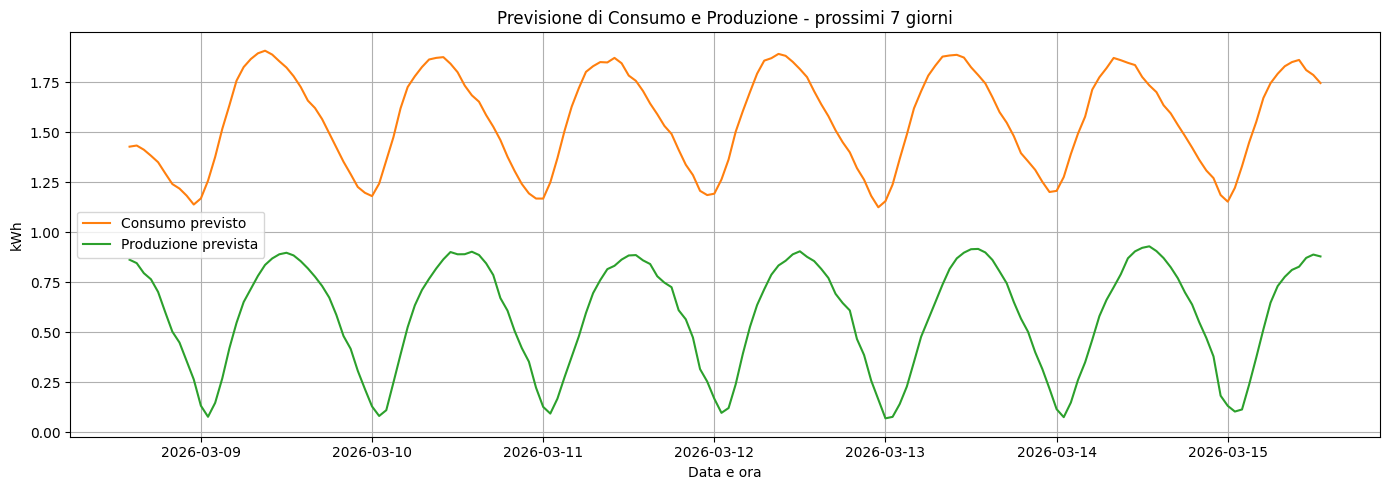

In [40]:
# 1. Produzione e consumo previsti
print("Generazione grafici riepilogativi...")

import matplotlib.dates as mdates

# 1. Produzione e consumo previsti
plt.figure(figsize=(14, 5))
plt.plot(df_forecast.index, df_forecast['forecasted_consumption'], label='Consumo previsto', color='tab:orange')
plt.plot(df_forecast.index, df_forecast['forecasted_production'], label='Produzione prevista', color='tab:green')
plt.title('Previsione di Consumo e Produzione - prossimi 7 giorni')
plt.xlabel('Data e ora')
plt.ylabel('kWh')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Energia da acquistare o cedere (differenza oraria)

✅ **Obiettivo**:
- Questo codice serve a visualizzare graficamente, su un orizzonte temporale, la quantità di energia che si prevede di dover acquistare dalla rete e quella che si prevede di cedere alla rete.

✅ **Descrizione**:
- Il codice crea una figura di dimensioni definite (14x5 pollici) e traccia due curve usando i dati temporali indicizzati in df_forecast: la quantità di energia da acquistare (to_buy, in rosso) e quella da cedere alla rete (to_grid, in blu). Imposta titolo, etichette degli assi, legenda e griglia, ottimizza il layout e mostra il grafico.

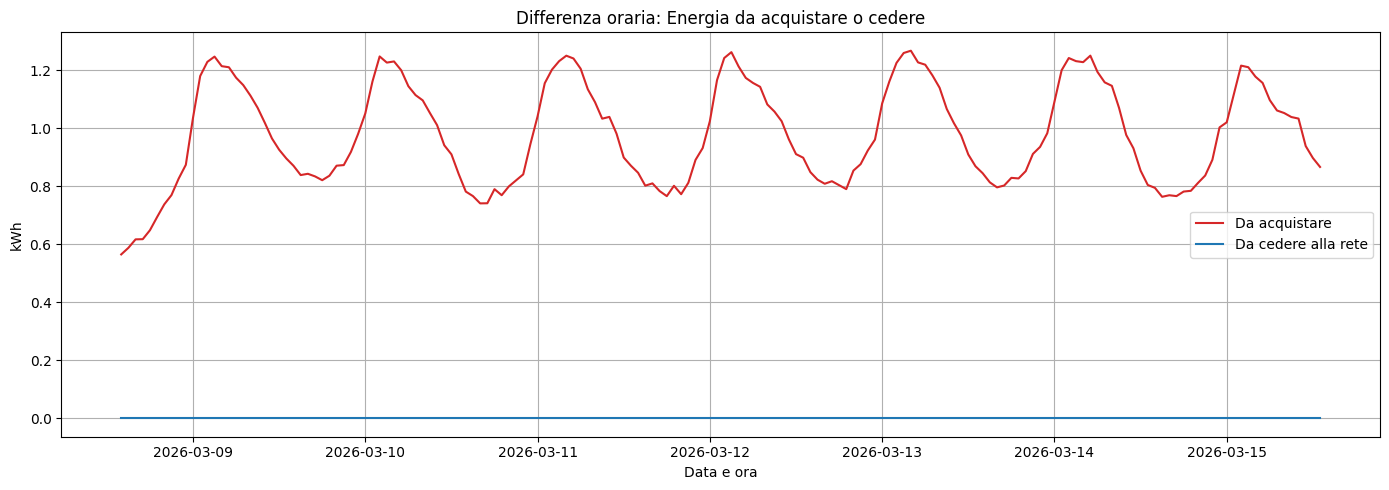

In [41]:
# 2. Energia da acquistare o cedere (differenza oraria)
plt.figure(figsize=(14, 5))
plt.plot(df_forecast.index, df_forecast['to_buy'], label='Da acquistare', color='tab:red')
plt.plot(df_forecast.index, df_forecast['to_grid'], label='Da cedere alla rete', color='tab:blue')
plt.title('Differenza oraria: Energia da acquistare o cedere')
plt.xlabel('Data e ora')
plt.ylabel('kWh')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 3. Grafico cumulativo

✅ **Obiettivo**:
- Questo codice serve a visualizzare l’andamento cumulativo nel tempo dell’energia da acquistare e di quella immessa in rete, per valutare l’accumulo totale su un periodo di 7 giorni.

✅ **Descrizione**:
- Calcola la somma cumulativa delle colonne to_buy e to_grid nel DataFrame df_forecast, creando due nuove colonne cumulative_buy e cumulative_grid. Poi disegna un grafico che mostra queste due quantità accumulate nel tempo, con titolo, etichette, legenda e griglia, per facilitarne l’interpretazione, e infine visualizza il grafico.

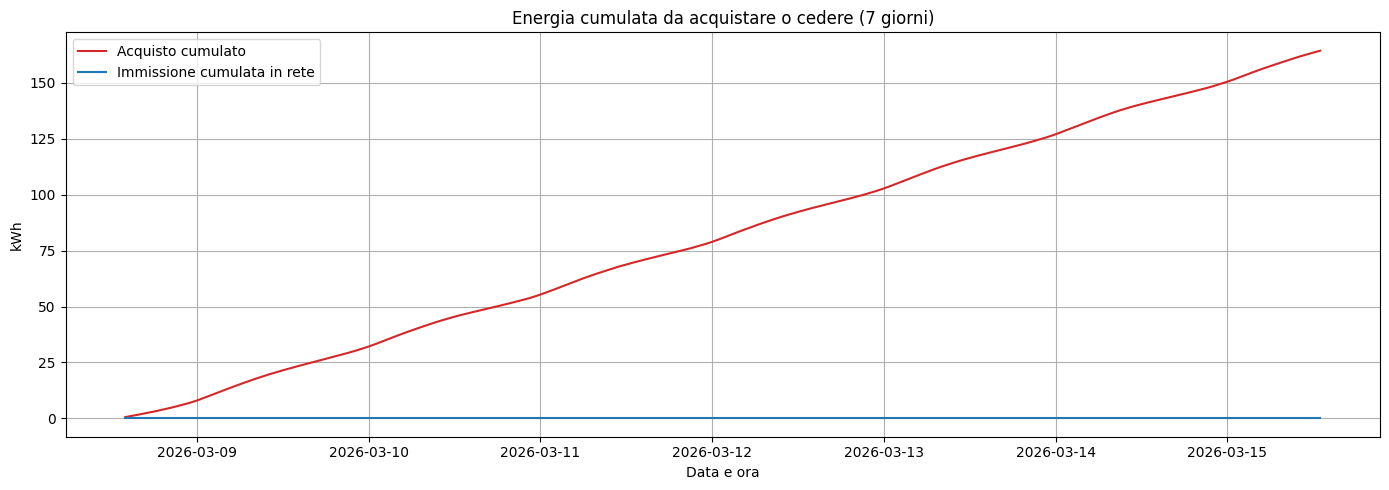

In [42]:
# 3. Grafico cumulativo
df_forecast['cumulative_buy'] = df_forecast['to_buy'].cumsum()
df_forecast['cumulative_grid'] = df_forecast['to_grid'].cumsum()

plt.figure(figsize=(14, 5))
plt.plot(df_forecast.index, df_forecast['cumulative_buy'], label='Acquisto cumulato', color='tab:red')
plt.plot(df_forecast.index, df_forecast['cumulative_grid'], label='Immissione cumulata in rete', color='tab:blue')
plt.title('Energia cumulata da acquistare o cedere (7 giorni)')
plt.xlabel('Data e ora')
plt.ylabel('kWh')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()